# Predicting Online Shopper Purchase Intention



## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             RocCurveDisplay, precision_recall_curve, auc)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Boosting Libraries
from xgboost import XGBClassifier
try:
    from lightgbm import LGBMClassifier
except Exception as lightgbm_error:
    class LGBMClassifier(GradientBoostingClassifier):
        def __init__(self, n_estimators=100, max_depth=3, learning_rate=0.1,
                     subsample=1.0, colsample_bytree=1.0, reg_alpha=0.0,
                     reg_lambda=0.0, random_state=None, n_jobs=None, verbose=-1):
            self.colsample_bytree = colsample_bytree
            self.reg_alpha = reg_alpha
            self.reg_lambda = reg_lambda
            self.n_jobs = n_jobs
            super().__init__(
                n_estimators=n_estimators,
                max_depth=max_depth,
                learning_rate=learning_rate,
                subsample=subsample,
                random_state=random_state,
                verbose=0 if verbose < 0 else verbose
            )

    print(f"LightGBM native library unavailable ({lightgbm_error}); using GradientBoostingClassifier-compatible fallback.")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("All libraries imported successfully.")

LightGBM native library unavailable (dlopen(/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightgbm/lib/lib_lightgbm.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib
  Referenced from: <D44045CD-B874-3A27-9A61-F131D99AACE4> /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightgbm/lib/lib_lightgbm.dylib
  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file)); using Grad

## 2. Load Dataset

In [ ]:
df = pd.read_csv('/Users/Desktop/Organized Files/07 - Excel and Data Files/online_shoppers_intention.csv')
print(f'Dataset Shape: {df.shape}')
print(f'Total Sessions: {len(df):,}')
print(f'Total Features: {df.shape[1]}')
df.head()

Dataset Shape: (12330, 18)
Total Sessions: 12,330
Total Features: 18


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Administrative,12330.0,NaN,NaN,NaN,2.315166,3.321784,0.0,0.0,1.0,4.0,27.0
Administrative_Duration,12330.0,NaN,NaN,NaN,80.818611,176.779107,0.0,0.0,7.5,93.25625,3398.75
Informational,12330.0,NaN,NaN,NaN,0.503569,1.270156,0.0,0.0,0.0,0.0,24.0
Informational_Duration,12330.0,NaN,NaN,NaN,34.472398,140.749294,0.0,0.0,0.0,0.0,2549.375
ProductRelated,12330.0,NaN,NaN,NaN,31.731468,44.475503,0.0,7.0,18.0,38.0,705.0
ProductRelated_Duration,12330.0,NaN,NaN,NaN,1194.74622,1913.669288,0.0,184.1375,598.936905,1464.157214,63973.52223
BounceRates,12330.0,NaN,NaN,NaN,0.022191,0.048488,0.0,0.0,0.003112,0.016813,0.2
ExitRates,12330.0,NaN,NaN,NaN,0.043073,0.048597,0.0,0.014286,0.025156,0.05,0.2
PageValues,12330.0,NaN,NaN,NaN,5.889258,18.568437,0.0,0.0,0.0,0.0,361.763742
SpecialDay,12330.0,NaN,NaN,NaN,0.061427,0.198917,0.0,0.0,0.0,0.0,1.0


## 4. Data Quality Check

### 4.1 Missing Values

In [5]:
missing = df.isnull().sum().reset_index()
missing.columns = ['Feature', 'Missing Count']
missing['Missing %'] = (missing['Missing Count'] / len(df) * 100).round(2)

if missing['Missing Count'].sum() > 0:
    print(missing[missing['Missing Count'] > 0].to_string(index=False))
else:
    print('No missing values found.')

No missing values found.


### 4.2 Duplicate Records

In [6]:
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
if dupes > 0:
    print(f'Removing {dupes} duplicate rows...')
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'New shape: {df.shape}')

Duplicate rows: 125
Removing 125 duplicate rows...
New shape: (12205, 18)


### 4.3 Data Types Summary

In [7]:
dtype_df = pd.DataFrame({
    'Feature': df.columns,
    'Data Type': df.dtypes.values,
    'Unique Values': df.nunique().values,
    'Sample Value': [df[col].iloc[0] for col in df.columns]
})
dtype_df

,Feature,Data Type,Unique Values,Sample Value
0,Administrative,int64,27,0
1,Administrative_Duration,float64,3335,0.0
2,Informational,int64,17,0
3,Informational_Duration,float64,1258,0.0
4,ProductRelated,int64,311,1
5,ProductRelated_Duration,float64,9551,0.0
6,BounceRates,float64,1872,0.2
7,ExitRates,float64,4777,0.2
8,PageValues,float64,2704,0.0
9,SpecialDay,float64,6,0.0


## 5. Target Variable Analysis — Revenue (Purchase Intention)

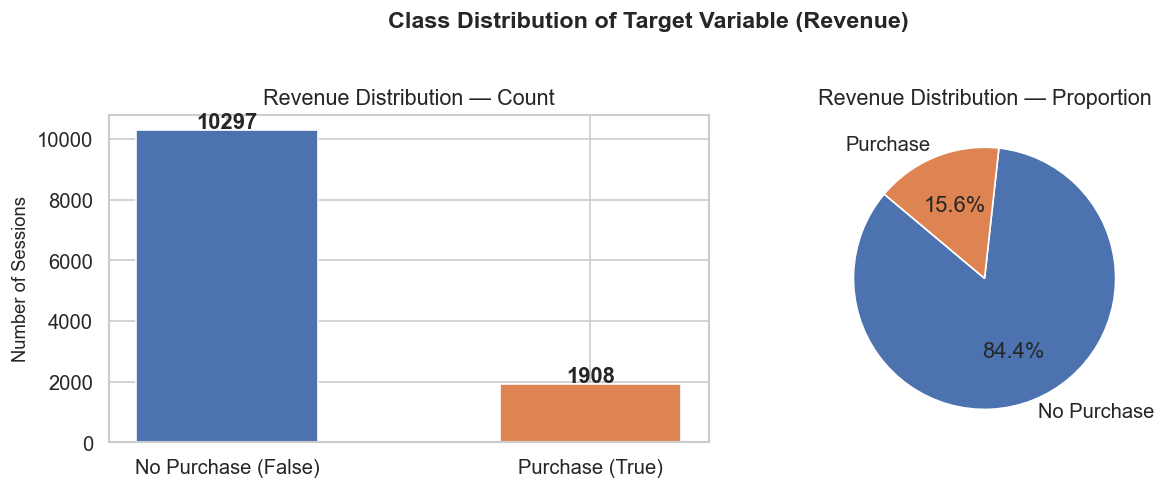

Purchase Sessions  : 1,908  (15.6%)
Non-Purchase Sessions: 10,297 (84.4%)
Class Imbalance Ratio: 1 : 5.4


In [8]:
revenue_counts = df['Revenue'].value_counts()
revenue_pct = df['Revenue'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['No Purchase (False)', 'Purchase (True)'], revenue_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for i, v in enumerate(revenue_counts.values):
    axes[0].text(i, v + 80, str(v), ha='center', fontweight='bold')
axes[0].set_title('Revenue Distribution — Count')
axes[0].set_ylabel('Number of Sessions')

axes[1].pie(revenue_counts.values, labels=['No Purchase', 'Purchase'], autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=140,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Revenue Distribution — Proportion')

plt.suptitle('Class Distribution of Target Variable (Revenue)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Purchase Sessions  : {revenue_counts[True]:,}  ({revenue_pct[True]:.1f}%)")
print(f"Non-Purchase Sessions: {revenue_counts[False]:,} ({revenue_pct[False]:.1f}%)")
print(f"Class Imbalance Ratio: 1 : {revenue_counts[False]/revenue_counts[True]:.1f}")

## 6. Univariate Analysis

### 6.1 Numerical Features — Distribution

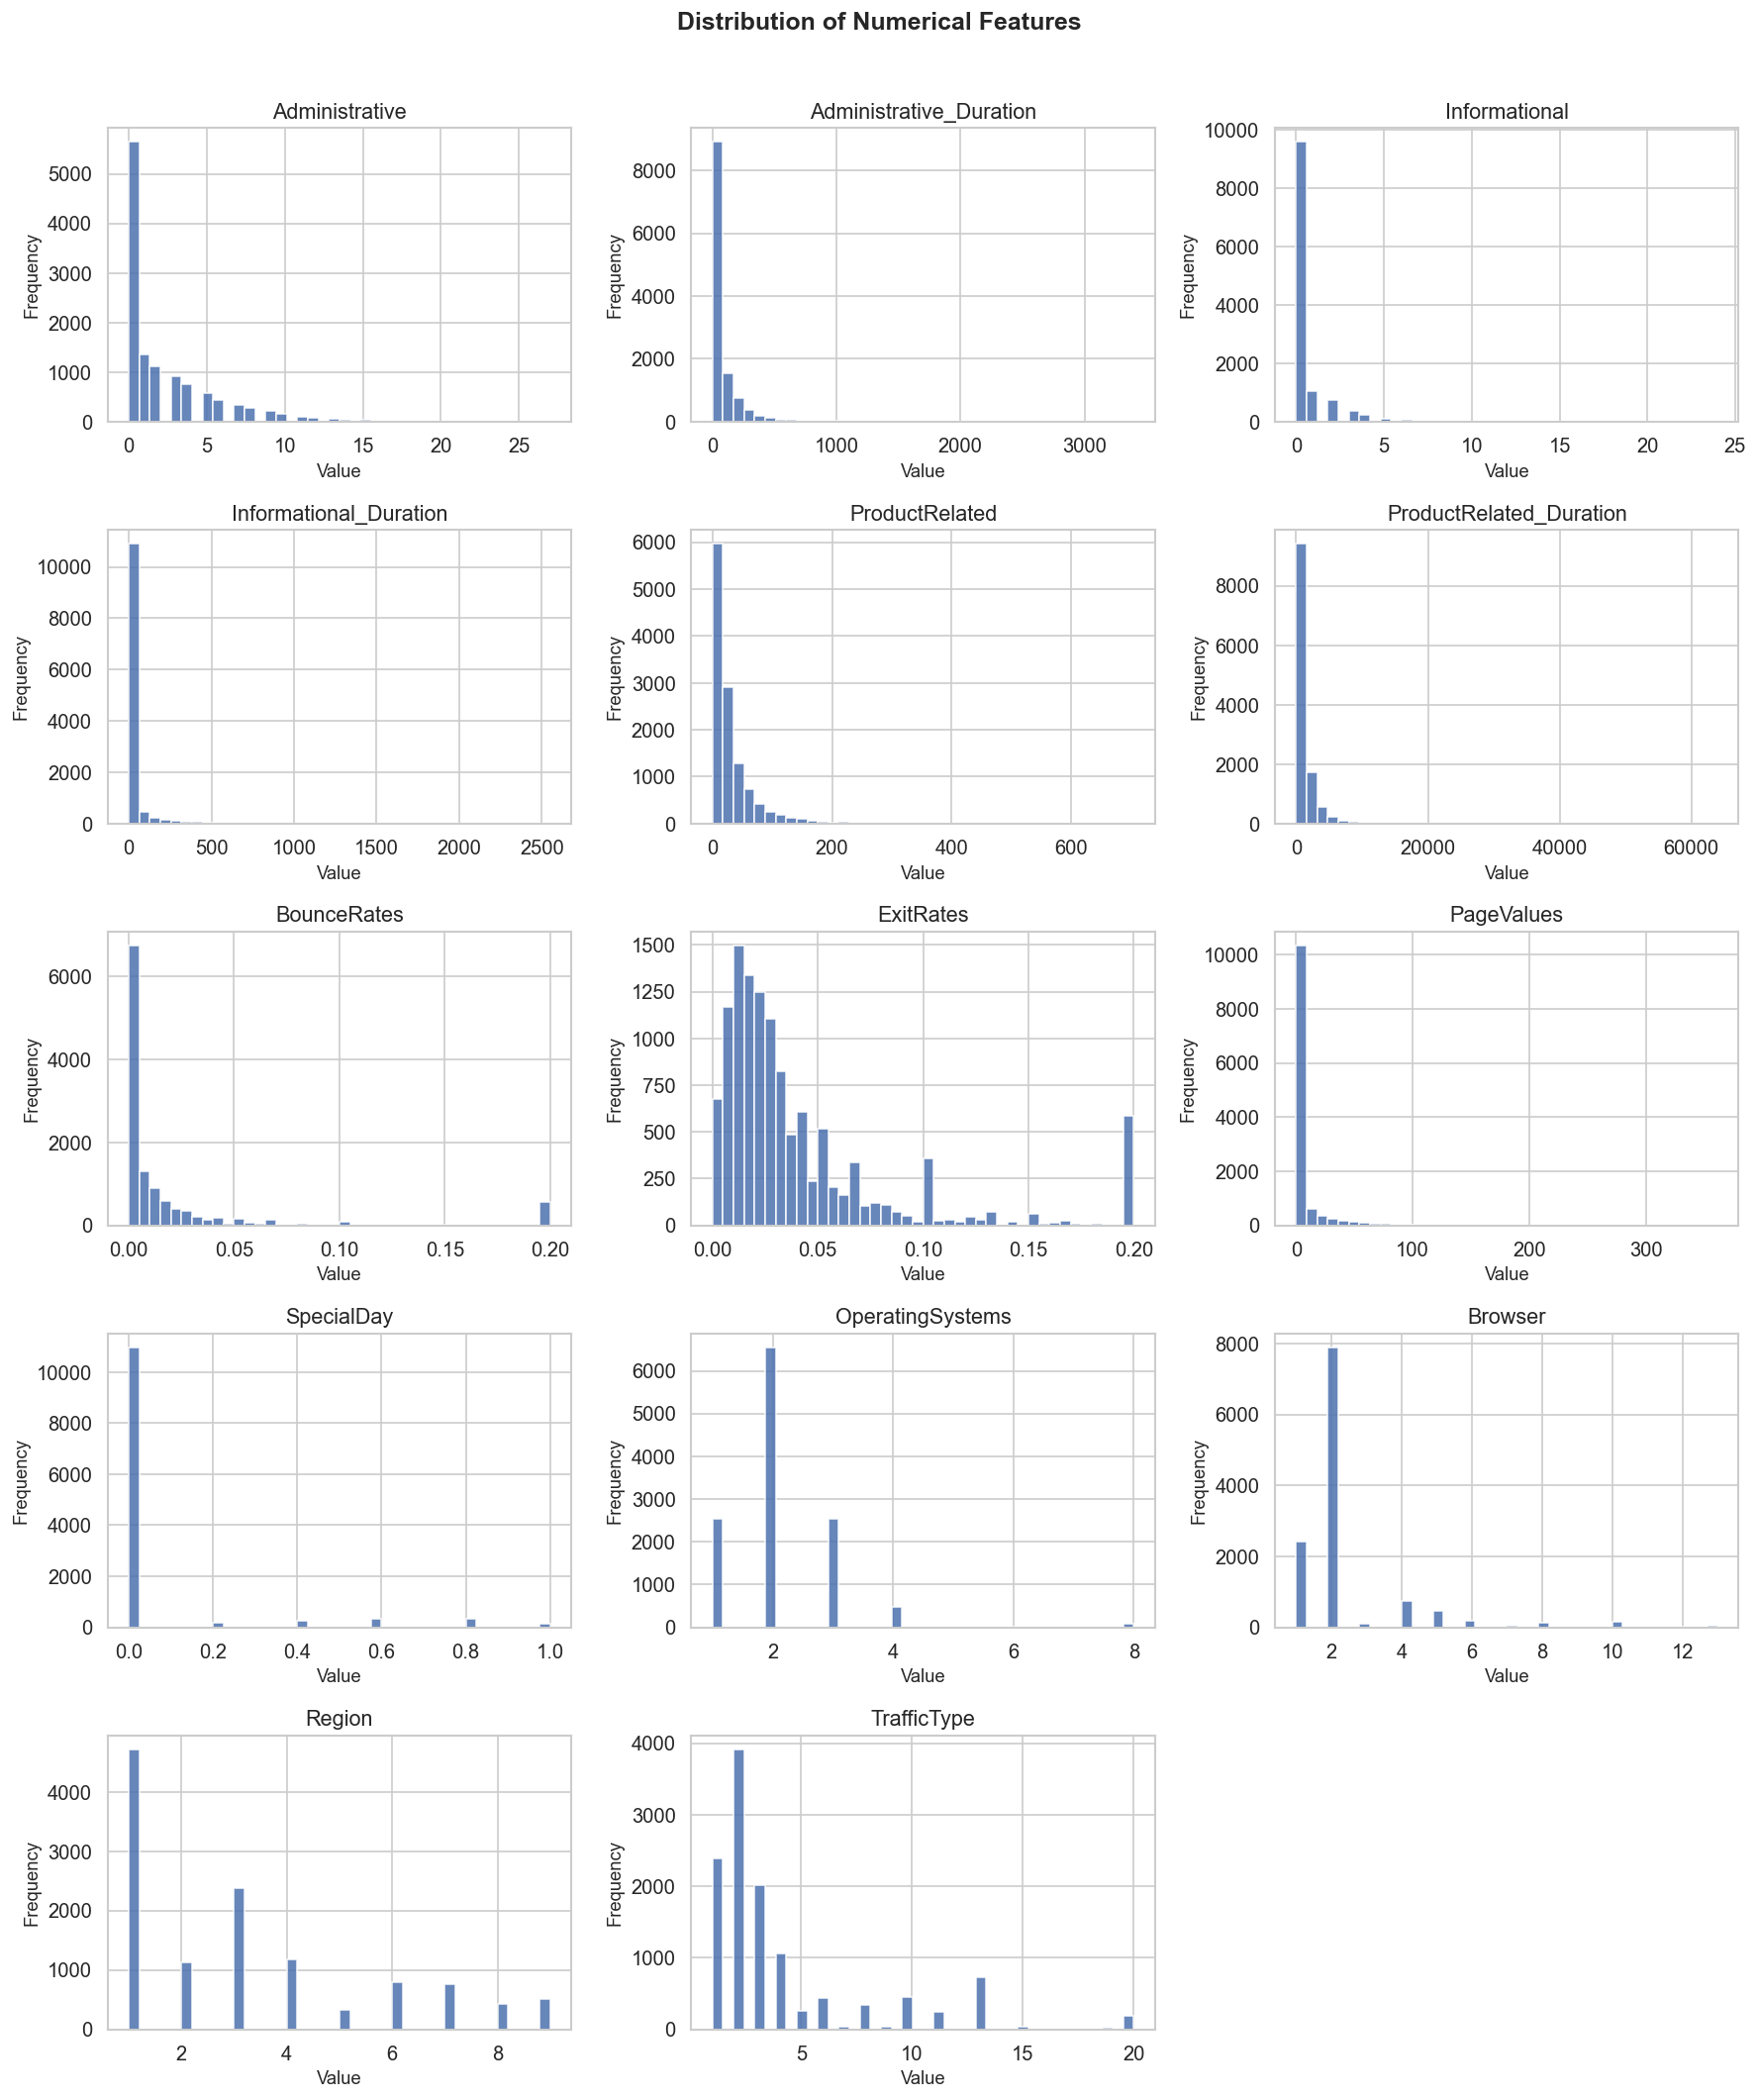

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.5 * n_rows))
axes = np.atleast_1d(axes).flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution of Numerical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 6.2 Categorical Features — Value Counts

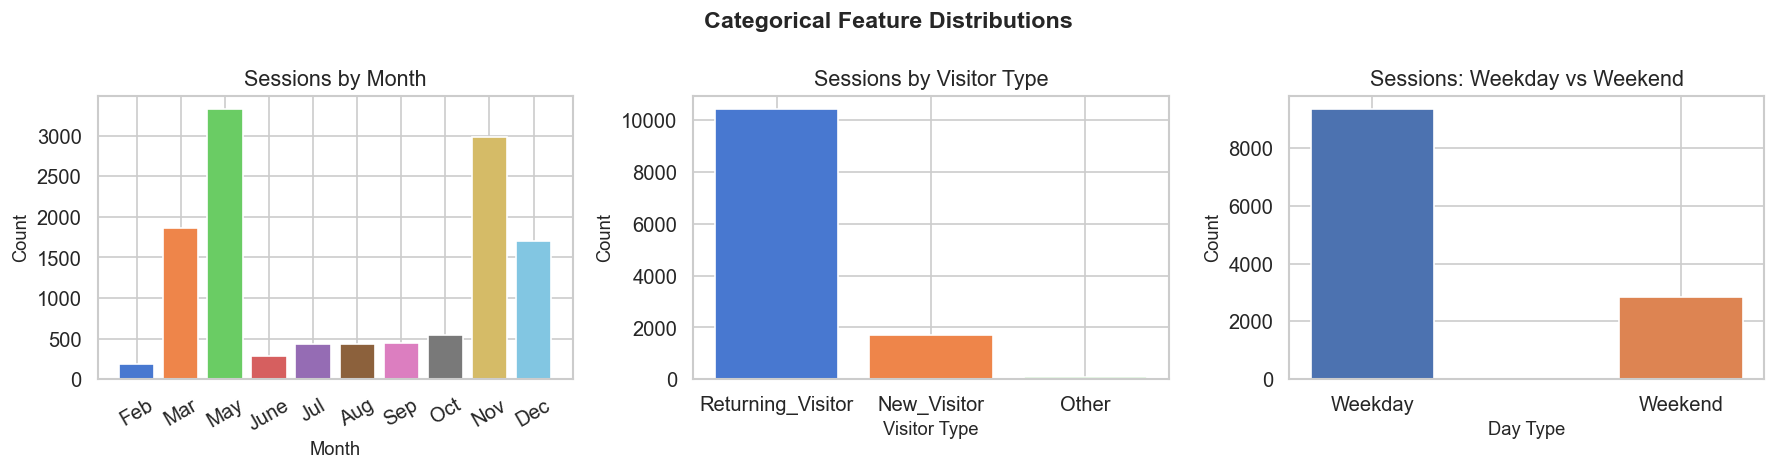

In [10]:
cat_cols = ['Month', 'VisitorType', 'Weekend']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_present = [m for m in month_order if m in df['Month'].unique()]

month_counts = df['Month'].value_counts().reindex(month_present)
axes[0].bar(month_counts.index, month_counts.values,
            color=sns.color_palette('muted', len(month_counts)), edgecolor='white')
axes[0].set_title('Sessions by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

vt_counts = df['VisitorType'].value_counts()
axes[1].bar(vt_counts.index, vt_counts.values,
            color=sns.color_palette('muted', len(vt_counts)), edgecolor='white')
axes[1].set_title('Sessions by Visitor Type')
axes[1].set_xlabel('Visitor Type')
axes[1].set_ylabel('Count')

we_counts = df['Weekend'].value_counts()
axes[2].bar(['Weekday', 'Weekend'], we_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.4)
axes[2].set_title('Sessions: Weekday vs Weekend')
axes[2].set_xlabel('Day Type')
axes[2].set_ylabel('Count')

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Bivariate Analysis — Features vs Target (Revenue)

### 7.1 Purchase Rate by Month

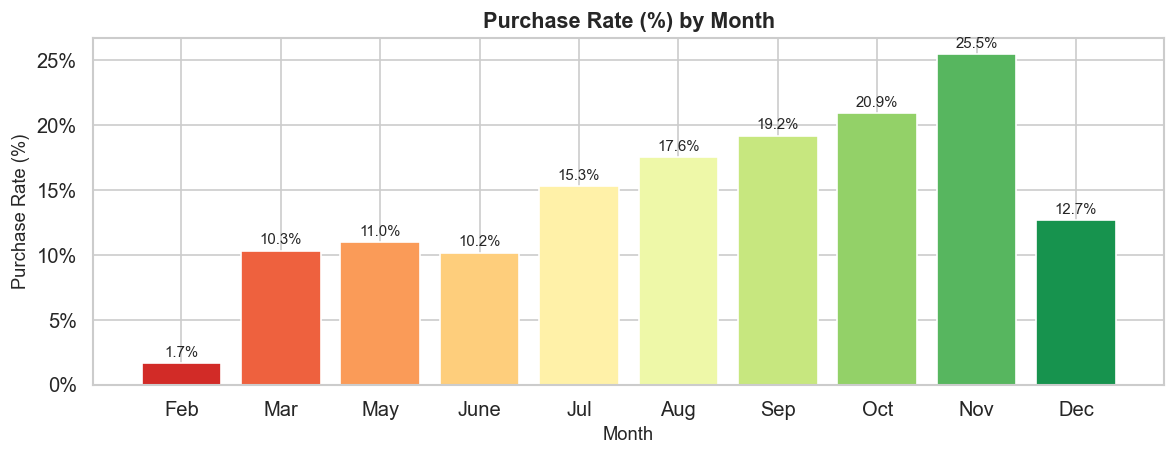

In [11]:
month_revenue = df.groupby('Month')['Revenue'].mean().reindex(month_present) * 100

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(month_revenue.index, month_revenue.values,
              color=sns.color_palette('RdYlGn', len(month_revenue)), edgecolor='white')
for bar, val in zip(bars, month_revenue.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_title('Purchase Rate (%) by Month', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Purchase Rate (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.show()

### 7.2 Purchase Rate by Visitor Type and Weekend

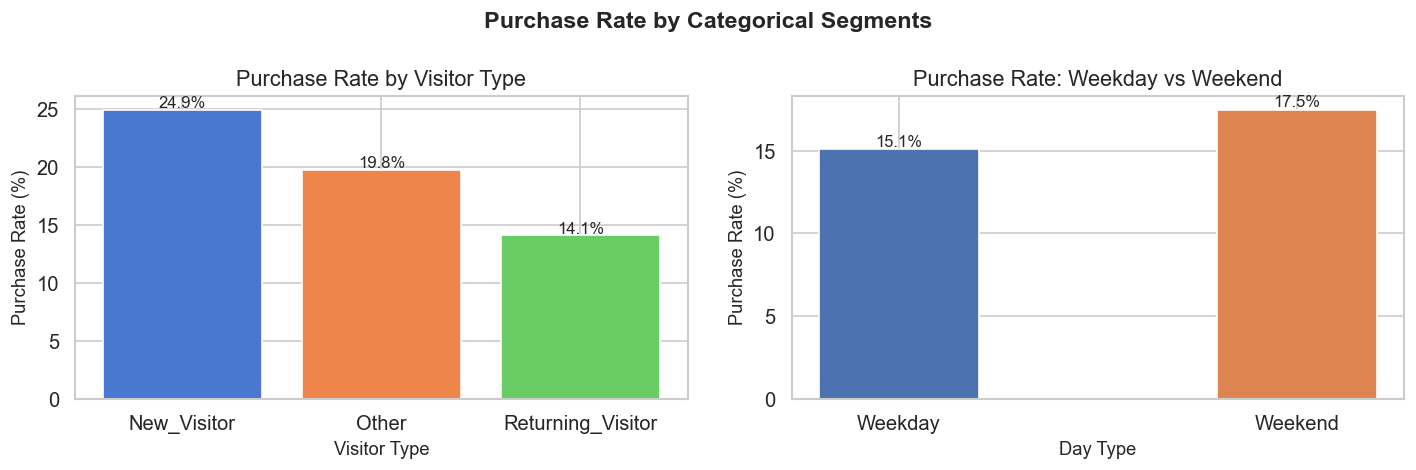

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vt_rate = df.groupby('VisitorType')['Revenue'].mean() * 100
axes[0].bar(vt_rate.index, vt_rate.values,
            color=sns.color_palette('muted', 3), edgecolor='white')
for i, v in enumerate(vt_rate.values):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10)
axes[0].set_title('Purchase Rate by Visitor Type')
axes[0].set_xlabel('Visitor Type')
axes[0].set_ylabel('Purchase Rate (%)')

we_rate = df.groupby('Weekend')['Revenue'].mean() * 100
axes[1].bar(['Weekday', 'Weekend'], we_rate.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.4)
for i, v in enumerate(we_rate.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10)
axes[1].set_title('Purchase Rate: Weekday vs Weekend')
axes[1].set_xlabel('Day Type')
axes[1].set_ylabel('Purchase Rate (%)')

plt.suptitle('Purchase Rate by Categorical Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 Numerical Features vs Revenue — Box Plots

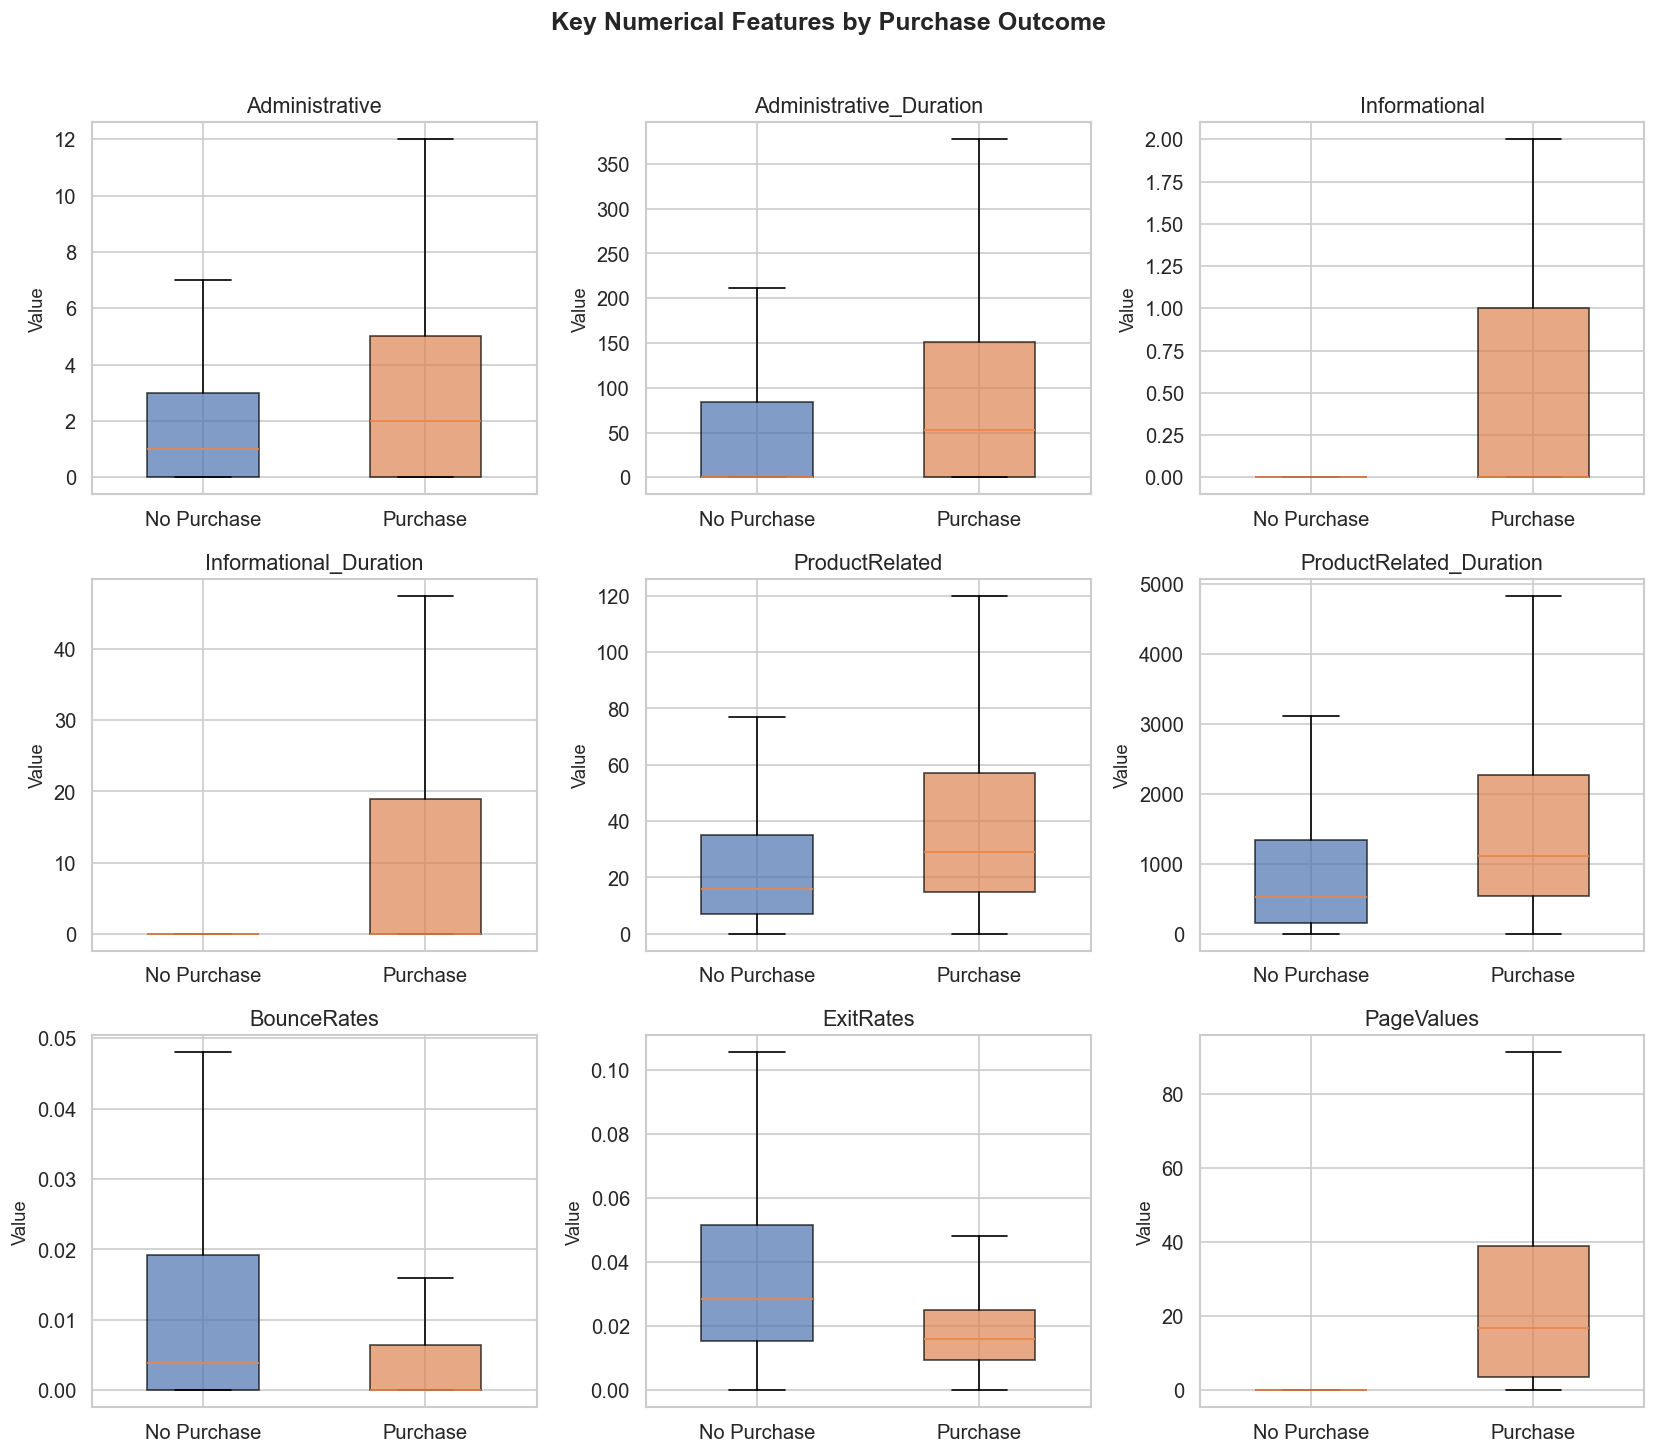

In [13]:
key_num = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
           'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(key_num):
    data_f = df[df['Revenue'] == False][col]
    data_t = df[df['Revenue'] == True][col]
    bp = axes[i].boxplot([data_f, data_t], labels=['No Purchase', 'Purchase'],
                          patch_artist=True, widths=0.5, showfliers=False)
    bp['boxes'][0].set_facecolor('#4C72B0')
    bp['boxes'][1].set_facecolor('#DD8452')
    for patch in bp['boxes']:
        patch.set_alpha(0.7)
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.suptitle('Key Numerical Features by Purchase Outcome', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 7.4 PageValues vs Revenue — Key Predictor Deep-Dive

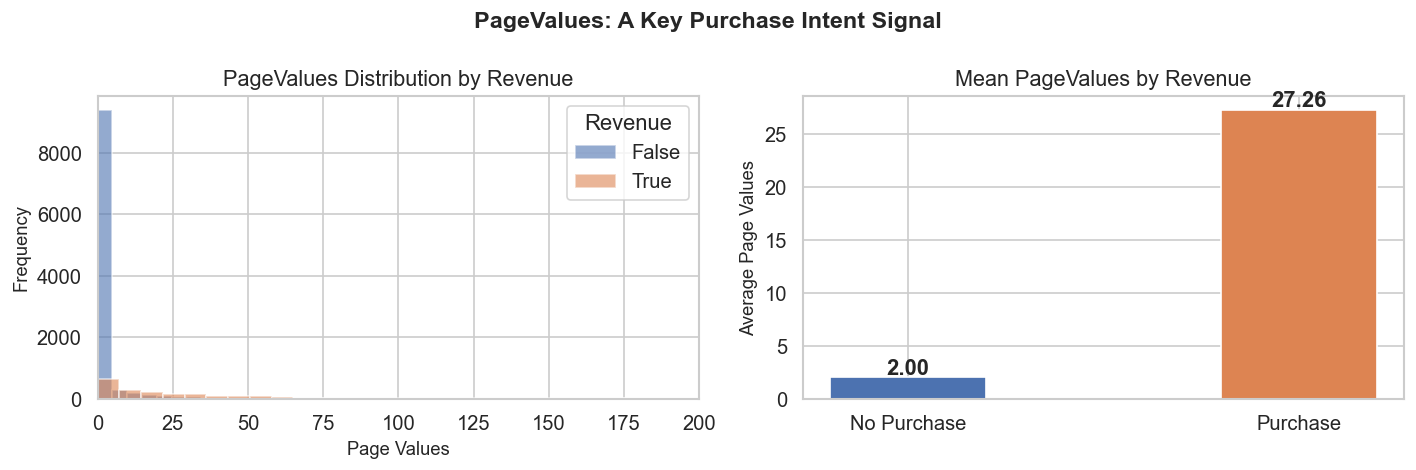

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color in [(False, '#4C72B0'), (True, '#DD8452')]:
    subset = df[df['Revenue'] == label]['PageValues']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=str(label), edgecolor='white')
axes[0].set_title('PageValues Distribution by Revenue')
axes[0].set_xlabel('Page Values')
axes[0].set_ylabel('Frequency')
axes[0].legend(title='Revenue')
axes[0].set_xlim(0, 200)

avg_pv = df.groupby('Revenue')['PageValues'].mean()
axes[1].bar(['No Purchase', 'Purchase'], avg_pv.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.4)
for i, v in enumerate(avg_pv.values):
    axes[1].text(i, v + 0.3, f'{v:.2f}', ha='center', fontweight='bold')
axes[1].set_title('Mean PageValues by Revenue')
axes[1].set_ylabel('Average Page Values')

plt.suptitle('PageValues: A Key Purchase Intent Signal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Multivariate Analysis

### 8.1 Correlation Heatmap (Numerical Features)

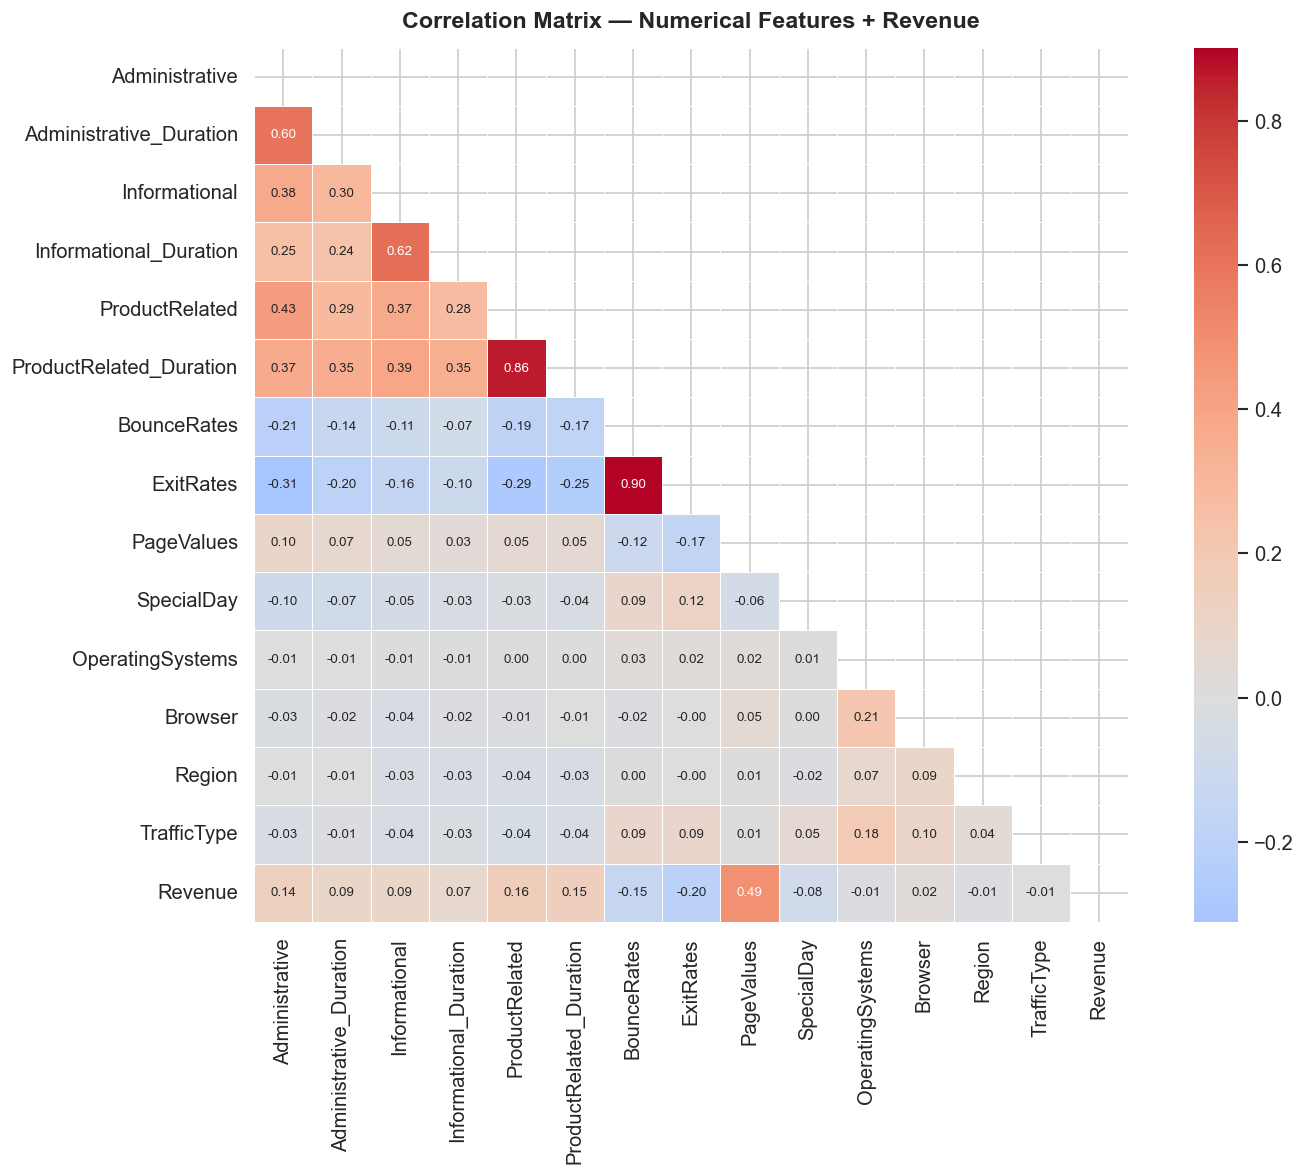

In [15]:
corr_df = df[num_cols].copy()
corr_df['Revenue'] = df['Revenue'].astype(int)
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Numerical Features + Revenue',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### 8.2 Feature Correlation with Revenue (Target Variable)


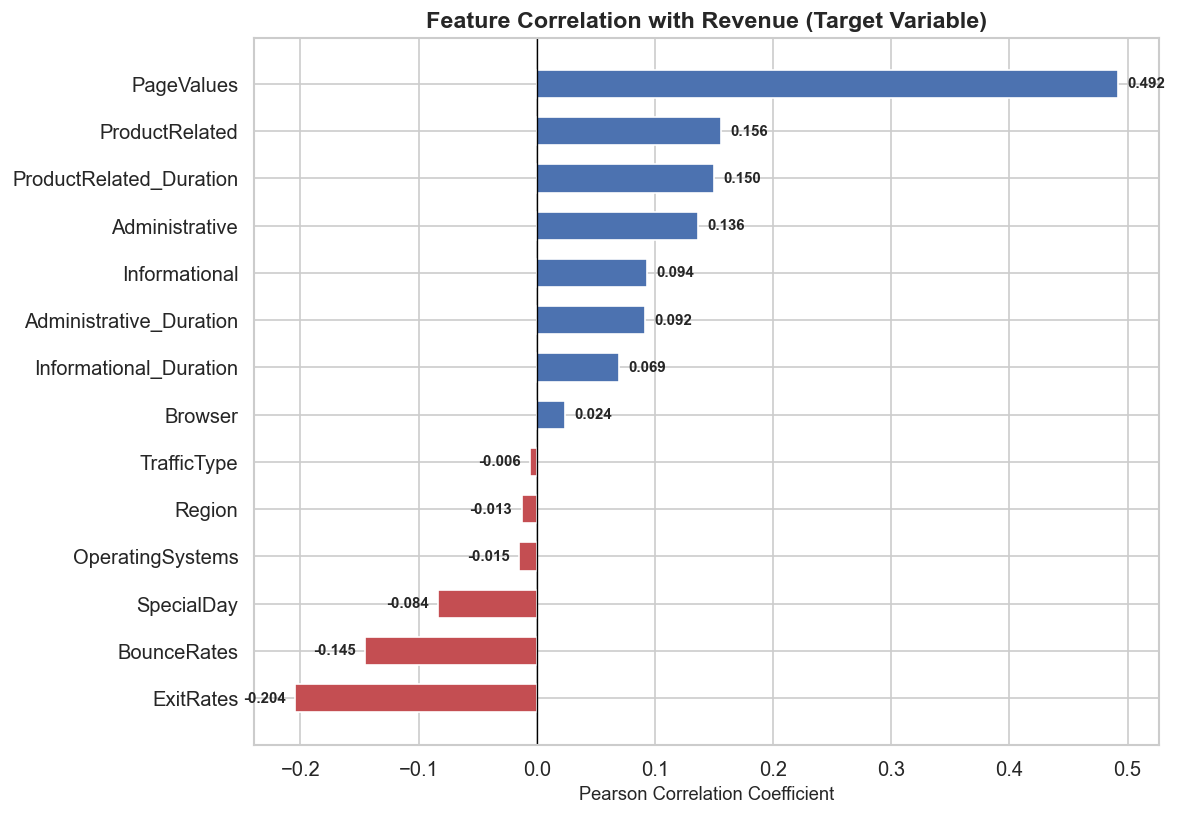


Top Positive Correlations with Revenue:
ProductRelated_Duration    0.150077
ProductRelated             0.156042
PageValues                 0.491894

Top Negative Correlations with Revenue:
ExitRates     -0.204320
BounceRates   -0.145091
SpecialDay    -0.083601


In [16]:
target_corr = corr_df.corr()['Revenue'].drop('Revenue').sort_values()

colors = ['#C44E52' if v < 0 else '#4C72B0' for v in target_corr.values]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Revenue (Target Variable)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')

for bar, val in zip(bars, target_corr.values):
    xpos = val + 0.008 if val >= 0 else val - 0.008
    ax.text(xpos, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=9,
            ha='left' if val >= 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTop Positive Correlations with Revenue:")
print(target_corr.tail(3).to_string())
print("\nTop Negative Correlations with Revenue:")
print(target_corr.head(3).to_string())

### 8.3 Pairplot — Top Correlated Features

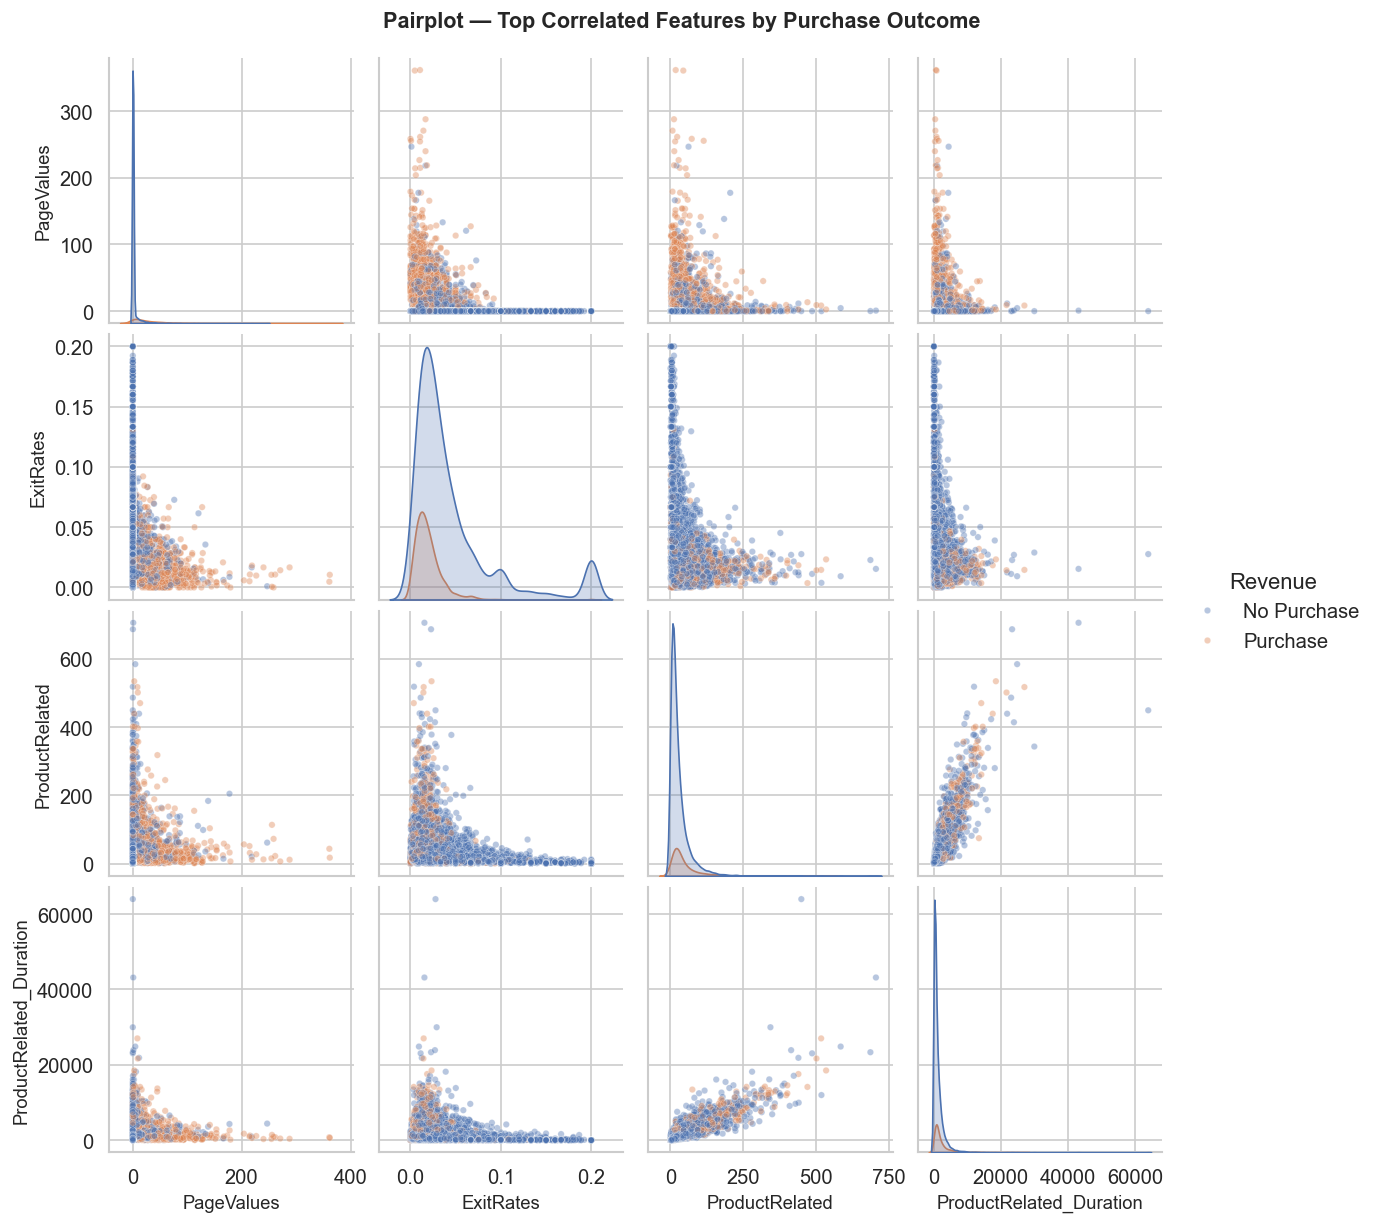

In [17]:
top_features = target_corr.abs().nlargest(4).index.tolist()
pair_df = df[top_features + ['Revenue']].copy()
pair_df['Revenue'] = pair_df['Revenue'].map({True: 'Purchase', False: 'No Purchase'})

g = sns.pairplot(pair_df, hue='Revenue',
                 palette={'Purchase': '#DD8452', 'No Purchase': '#4C72B0'},
                 plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde')
g.fig.suptitle('Pairplot — Top Correlated Features by Purchase Outcome',
               y=1.02, fontsize=13, fontweight='bold')
plt.show()

### 8.4 BounceRates vs ExitRates by Revenue

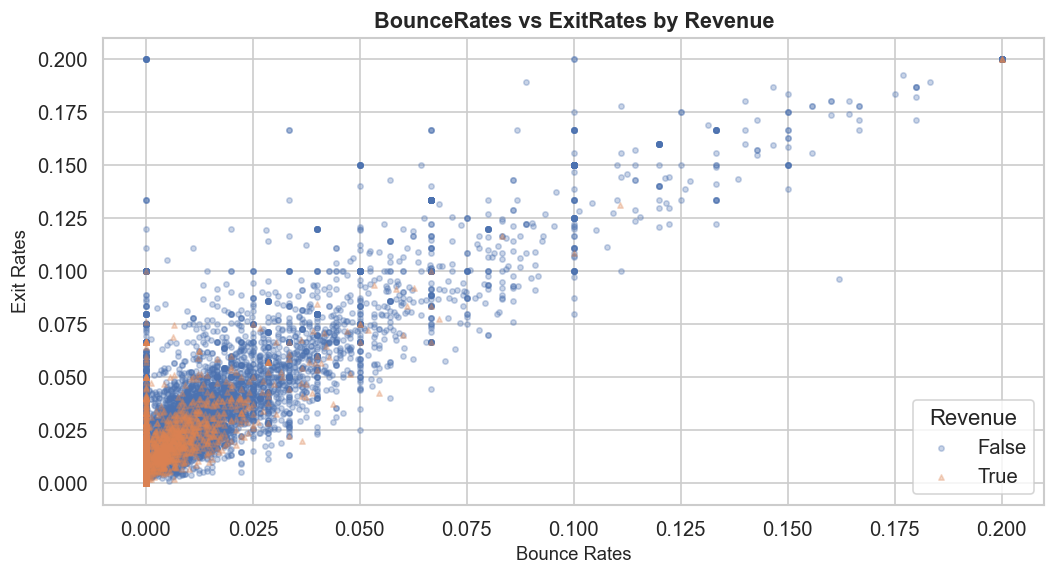

BounceRates vs ExitRates correlation: 0.902 (high collinearity)


In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

for label, color, marker in [(False, '#4C72B0', 'o'), (True, '#DD8452', '^')]:
    subset = df[df['Revenue'] == label]
    ax.scatter(subset['BounceRates'], subset['ExitRates'], c=color, label=str(label),
               alpha=0.3, s=10, marker=marker)

ax.set_title('BounceRates vs ExitRates by Revenue', fontweight='bold')
ax.set_xlabel('Bounce Rates')
ax.set_ylabel('Exit Rates')
ax.legend(title='Revenue')
plt.tight_layout()
plt.show()

bounce_exit_corr = df['BounceRates'].corr(df['ExitRates'])
print(f"BounceRates vs ExitRates correlation: {bounce_exit_corr:.3f} (high collinearity)")

## 9. Outlier Detection

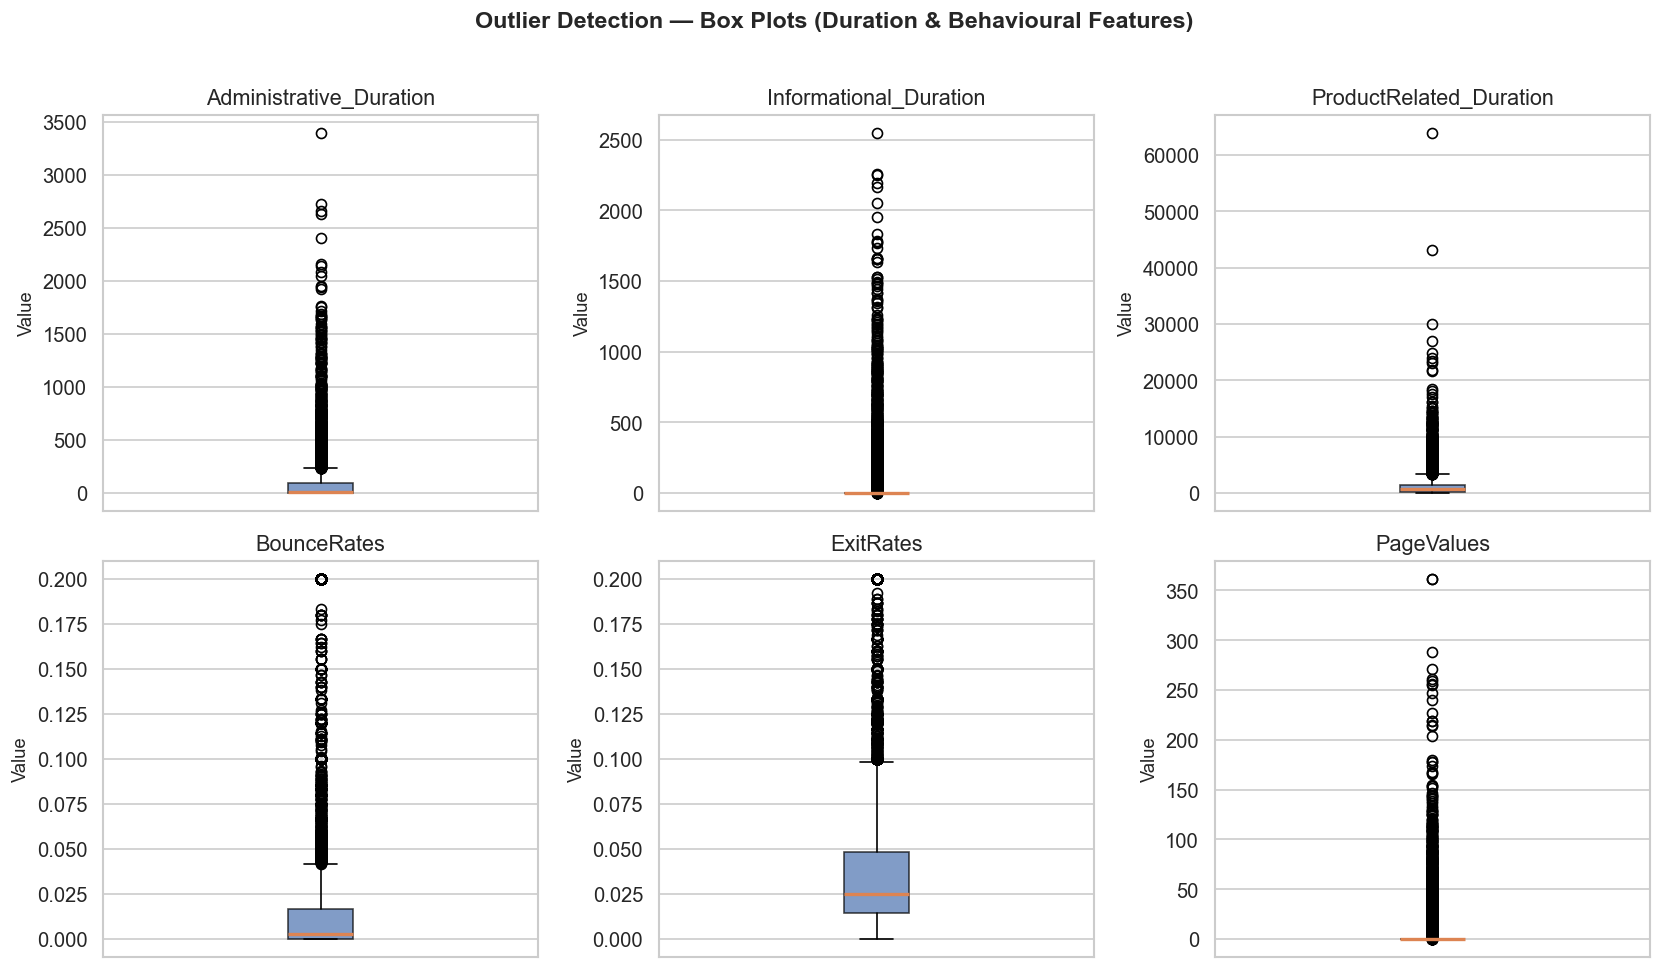

In [19]:
outlier_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
                'BounceRates', 'ExitRates', 'PageValues']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                    medianprops=dict(color='#DD8452', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

plt.suptitle('Outlier Detection — Box Plots (Duration & Behavioural Features)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [20]:
outlier_summary = []
for col in outlier_cols:
    z = np.abs(stats.zscore(df[col].dropna()))
    n_outliers = (z > 3).sum()
    pct = n_outliers / len(df) * 100
    outlier_summary.append({'Feature': col, 'Outliers (|z|>3)': n_outliers, 'Outlier %': round(pct, 2)})

pd.DataFrame(outlier_summary)

,Feature,Outliers (|z|>3),Outlier %
0,Administrative_Duration,230,1.88
1,Informational_Duration,229,1.88
2,ProductRelated_Duration,217,1.78
3,BounceRates,593,4.86
4,ExitRates,599,4.91
5,PageValues,257,2.11


## 10. Feature Engineering

### 10.1 Session Intensity — Total Pages & Duration

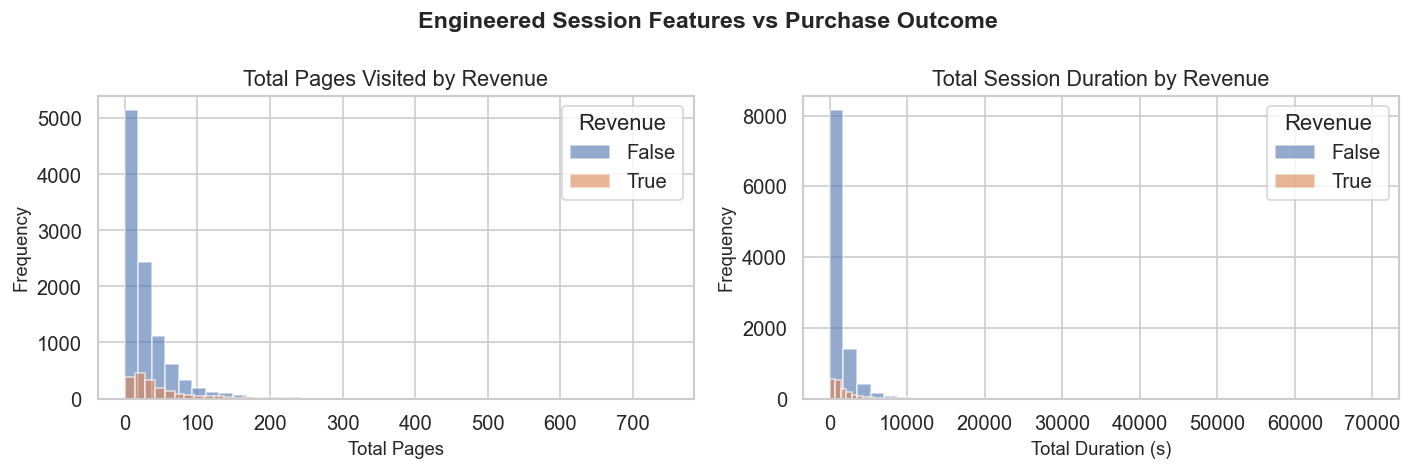

In [21]:
df['Total_Pages'] = df['Administrative'] + df['Informational'] + df['ProductRelated']
df['Total_Duration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color in [(False, '#4C72B0'), (True, '#DD8452')]:
    subset = df[df['Revenue'] == label]
    axes[0].hist(subset['Total_Pages'], bins=40, alpha=0.6, color=color, label=str(label), edgecolor='white')
    axes[1].hist(subset['Total_Duration'], bins=40, alpha=0.6, color=color, label=str(label), edgecolor='white')

axes[0].set_title('Total Pages Visited by Revenue')
axes[0].set_xlabel('Total Pages')
axes[0].set_ylabel('Frequency')
axes[0].legend(title='Revenue')

axes[1].set_title('Total Session Duration by Revenue')
axes[1].set_xlabel('Total Duration (s)')
axes[1].set_ylabel('Frequency')
axes[1].legend(title='Revenue')

plt.suptitle('Engineered Session Features vs Purchase Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.2 Product-Related Engagement Ratio

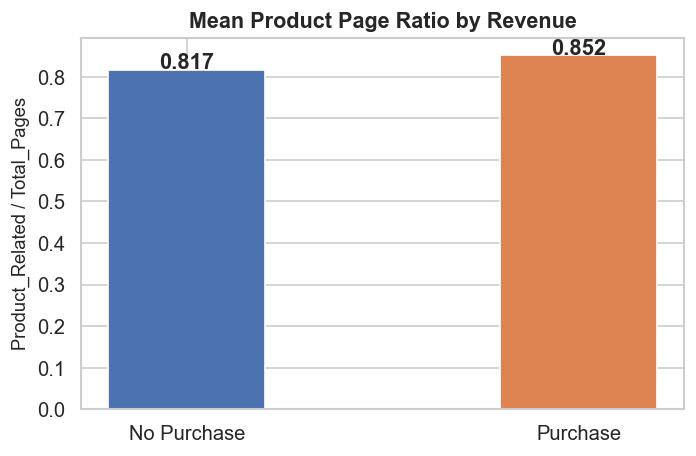

In [22]:
df['Product_Ratio'] = df['ProductRelated'] / (df['Total_Pages'] + 1)

avg_ratio = df.groupby('Revenue')['Product_Ratio'].mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['No Purchase', 'Purchase'], avg_ratio.values,
       color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.4)
for i, v in enumerate(avg_ratio.values):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold')
ax.set_title('Mean Product Page Ratio by Revenue', fontweight='bold')
ax.set_ylabel('Product_Related / Total_Pages')
plt.tight_layout()
plt.show()

## 11. EDA Summary

In [23]:
summary = {
    'Total Sessions': len(df),
    'Purchase Sessions': int(df['Revenue'].sum()),
    'Non-Purchase Sessions': int((~df['Revenue']).sum()),
    'Purchase Rate (%)': round(df['Revenue'].mean() * 100, 2),
    'Total Features (incl. engineered)': df.shape[1],
    'Missing Values': int(df.isnull().sum().sum()),
    'Duplicate Rows': int(df.duplicated().sum()),
    'Numerical Features': len(num_cols),
    'Categorical Features': len(cat_cols),
    'Months Covered': df['Month'].nunique(),
    'Top Correlated Feature': target_corr.abs().idxmax(),
    'Top Corr. Value': round(target_corr.abs().max(), 3)
}

summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])
summary_df.index.name = 'Metric'
summary_df

,Value
Metric,
Total Sessions,12205
Purchase Sessions,1908
Non-Purchase Sessions,10297
Purchase Rate (%),15.63
Total Features (incl. engineered),21
Missing Values,0
Duplicate Rows,0
Numerical Features,14
Categorical Features,3



# PART 2 — Machine Learning Pipeline


## 12. Prepare Features and Target

In [24]:
X = df.drop(columns=['Revenue'])
y = df['Revenue'].astype(int)

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nTarget balance: {y.value_counts(normalize=True).round(3).to_dict()}")

Feature matrix shape: (12205, 20)
Target distribution:
Revenue
0    10297
1     1908
Name: count, dtype: int64

Target balance: {0: 0.844, 1: 0.156}


## 13. Identify Categorical and Numerical Columns

In [25]:
categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): {numerical_features}")

Categorical features (3): ['Month', 'VisitorType', 'Weekend']
Numerical features (17): ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Total_Pages', 'Total_Duration', 'Product_Ratio']


## 14. Train-Test Split (80/20, Stratified)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTesting target distribution:\n{y_test.value_counts()}")

Training set: 9764 samples
Testing set:  2441 samples

Training target distribution:
Revenue
0    8238
1    1526
Name: count, dtype: int64

Testing target distribution:
Revenue
0    2059
1     382
Name: count, dtype: int64


## 15. Create Preprocessor


In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

print("Preprocessor created with:")
print(f"  - OneHotEncoder for: {categorical_features}")
print(f"  - StandardScaler for: {numerical_features}")

Preprocessor created with:
  - OneHotEncoder for: ['Month', 'VisitorType', 'Weekend']
  - StandardScaler for: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Total_Pages', 'Total_Duration', 'Product_Ratio']


## 16. SMOTE — Handling Class Imbalance


In [ ]:

print("=== Class Distribution BEFORE SMOTE ===")
print(f"Training set target distribution:")
print(y_train.value_counts())
print(f"\nImbalance ratio: 1 : {y_train.value_counts()[0] / y_train.value_counts()[1]:.1f}")


X_train_preprocessed = preprocessor.fit_transform(X_train)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_preprocessed, y_train)

print(f"\n=== Class Distribution AFTER SMOTE ===")
print(f"Resampled training set:")
print(pd.Series(y_train_resampled).value_counts())
print(f"\nTraining samples increased from {len(y_train)} to {len(y_train_resampled)}")

=== Class Distribution BEFORE SMOTE ===
Training set target distribution:
Revenue
0    8238
1    1526
Name: count, dtype: int64

Imbalance ratio: 1 : 5.4

=== Class Distribution AFTER SMOTE ===
Resampled training set:
Revenue
1    8238
0    8238
Name: count, dtype: int64

Training samples increased from 9764 to 16476


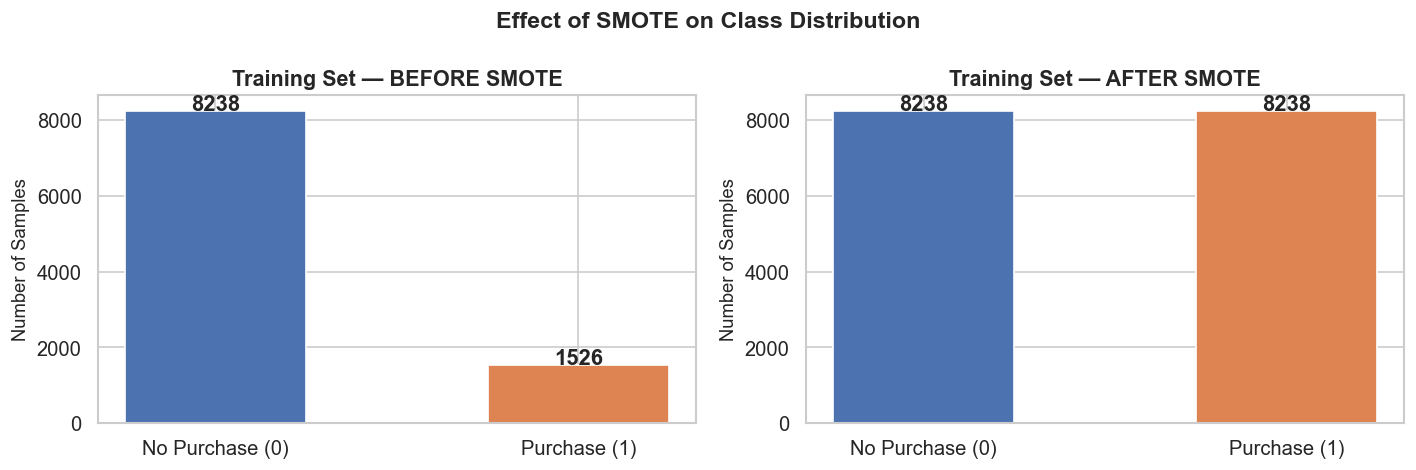

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts_before = y_train.value_counts()
axes[0].bar(['No Purchase (0)', 'Purchase (1)'], counts_before.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for i, v in enumerate(counts_before.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[0].set_title('Training Set — BEFORE SMOTE', fontweight='bold')
axes[0].set_ylabel('Number of Samples')

counts_after = pd.Series(y_train_resampled).value_counts()
axes[1].bar(['No Purchase (0)', 'Purchase (1)'], counts_after.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for i, v in enumerate(counts_after.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[1].set_title('Training Set — AFTER SMOTE', fontweight='bold')
axes[1].set_ylabel('Number of Samples')

plt.suptitle('Effect of SMOTE on Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 17. Define Model Pipelines (All Classifiers with SMOTE)


In [ ]:

rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])


xgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])


lgbm_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LGBMClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])


lr_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver='lbfgs',
        random_state=42,
        n_jobs=-1
    ))
])


pipelines = {
    'Random Forest': rf_pipeline,
    'XGBoost': xgb_pipeline,
    'LightGBM': lgbm_pipeline,
    'Logistic Regression': lr_pipeline
}

print(f"Defined {len(pipelines)} model pipelines, all with SMOTE:")
for name in pipelines:
    print(f"  ✓ {name}")

Defined 4 model pipelines, all with SMOTE:
  ✓ Random Forest
  ✓ XGBoost
  ✓ LightGBM
  ✓ Logistic Regression


## 18. Cross-Validation — All Models (5-Fold Stratified)

In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

print("5-Fold Stratified Cross-Validation (ROC-AUC):")
print("=" * 55)

for name, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s} | Mean: {scores.mean():.4f} ± {scores.std():.4f}")

print("=" * 55)

5-Fold Stratified Cross-Validation (ROC-AUC):
Random Forest             | Mean: 0.9258 ± 0.0045
XGBoost                   | Mean: 0.9218 ± 0.0056
LightGBM                  | Mean: 0.9232 ± 0.0056
Logistic Regression       | Mean: 0.8990 ± 0.0118


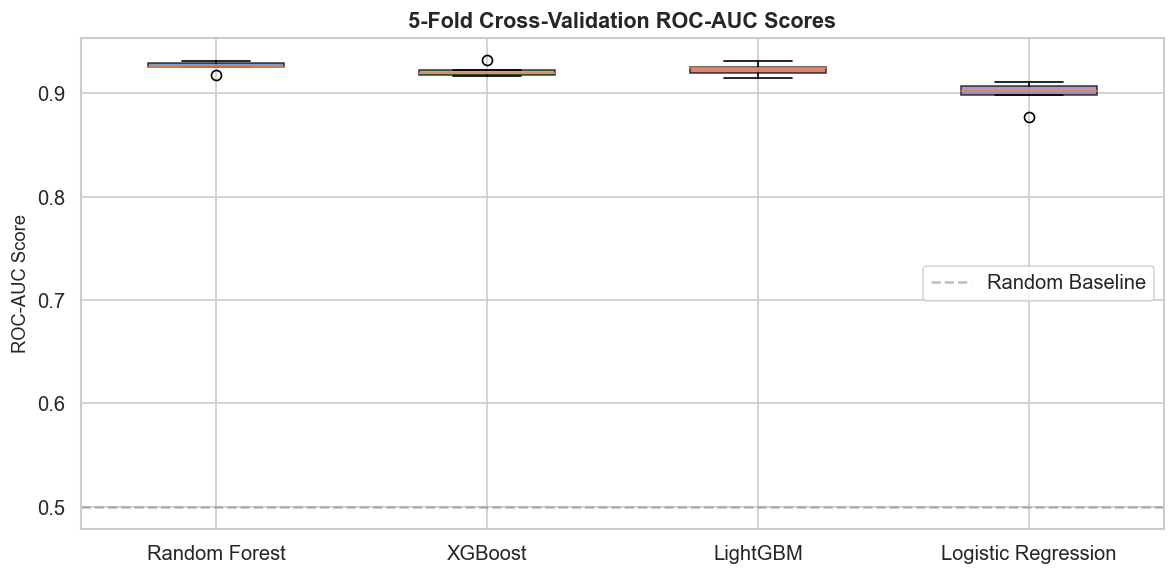

In [ ]:

fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [cv_results[name] for name in pipelines]
bp = ax.boxplot(cv_data, labels=list(pipelines.keys()), patch_artist=True, widths=0.5)

colors_box = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('5-Fold Cross-Validation ROC-AUC Scores', fontweight='bold', fontsize=13)
ax.set_ylabel('ROC-AUC Score')
ax.axhline(y=0.5, color='grey', linestyle='--', alpha=0.5, label='Random Baseline')
ax.legend()
plt.tight_layout()
plt.show()

## 19. Train All Models

In [33]:
trained_models = {}
predictions = {}
probabilities = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    predictions[name] = pipeline.predict(X_test)
    probabilities[name] = pipeline.predict_proba(X_test)[:, 1]
    print(f"✓ {name} trained and predictions generated.")

print(f"\nAll {len(trained_models)} models trained successfully.")

✓ Random Forest trained and predictions generated.
✓ XGBoost trained and predictions generated.
✓ LightGBM trained and predictions generated.
✓ Logistic Regression trained and predictions generated.

All 4 models trained successfully.


## 20. Model Performance Comparison

In [34]:
results_list = []

for name in pipelines:
    y_pred = predictions[name]
    y_proba = probabilities[name]
    
    results_list.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba), 4)
    })

results_df = pd.DataFrame(results_list).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("=" * 80)
print("           MODEL PERFORMANCE COMPARISON (TEST SET)")
print("=" * 80)
results_df

           MODEL PERFORMANCE COMPARISON (TEST SET)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.8914,0.6275,0.7539,0.6849,0.9286
1,XGBoost,0.8988,0.6781,0.6728,0.6754,0.9276
2,LightGBM,0.8910,0.6526,0.6492,0.6509,0.9242
3,Logistic Regression,0.8419,0.4967,0.7853,0.6085,0.9107


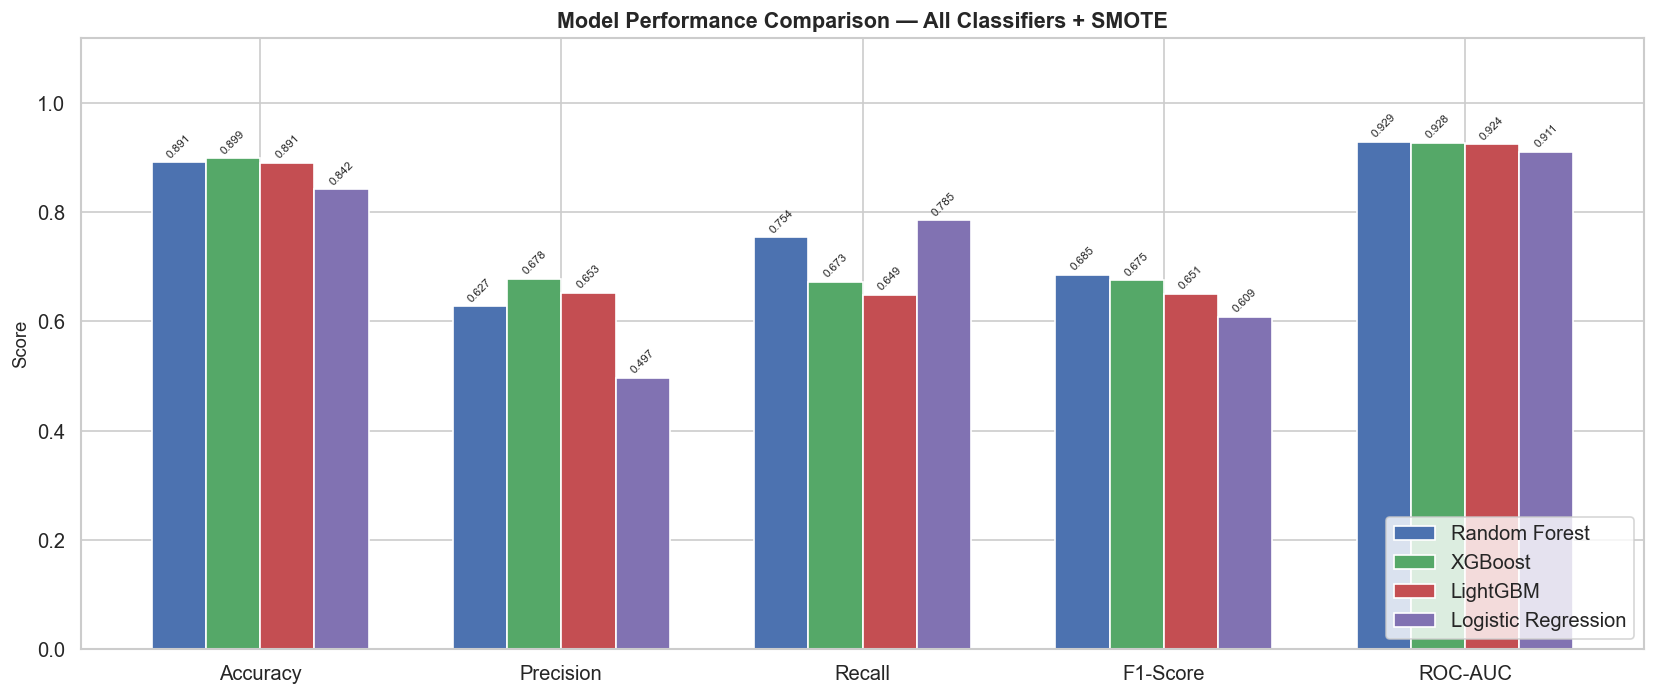

In [ ]:

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names = results_df['Model'].tolist()

x = np.arange(len(metrics_to_plot))
width = 0.18
colors_bar = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(14, 6))

for i, model in enumerate(model_names):
    vals = results_df[results_df['Model'] == model][metrics_to_plot].values[0]
    bars = ax.bar(x + i * width, vals, width, label=model, color=colors_bar[i], edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — All Classifiers + SMOTE', fontweight='bold', fontsize=13)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.12)
plt.tight_layout()
plt.show()

## 21. Classification Reports — All Models

In [36]:
for name in pipelines:
    print("=" * 60)
    print(f"  {name}")
    print("=" * 60)
    print(classification_report(y_test, predictions[name], target_names=['No Purchase', 'Purchase']))
    print()

  Random Forest
              precision    recall  f1-score   support

 No Purchase       0.95      0.92      0.93      2059
    Purchase       0.63      0.75      0.68       382

    accuracy                           0.89      2441
   macro avg       0.79      0.84      0.81      2441
weighted avg       0.90      0.89      0.90      2441


  XGBoost
              precision    recall  f1-score   support

 No Purchase       0.94      0.94      0.94      2059
    Purchase       0.68      0.67      0.68       382

    accuracy                           0.90      2441
   macro avg       0.81      0.81      0.81      2441
weighted avg       0.90      0.90      0.90      2441


  LightGBM
              precision    recall  f1-score   support

 No Purchase       0.93      0.94      0.94      2059
    Purchase       0.65      0.65      0.65       382

    accuracy                           0.89      2441
   macro avg       0.79      0.79      0.79      2441
weighted avg       0.89      0.89  

## 22. Confusion Matrices — All Models

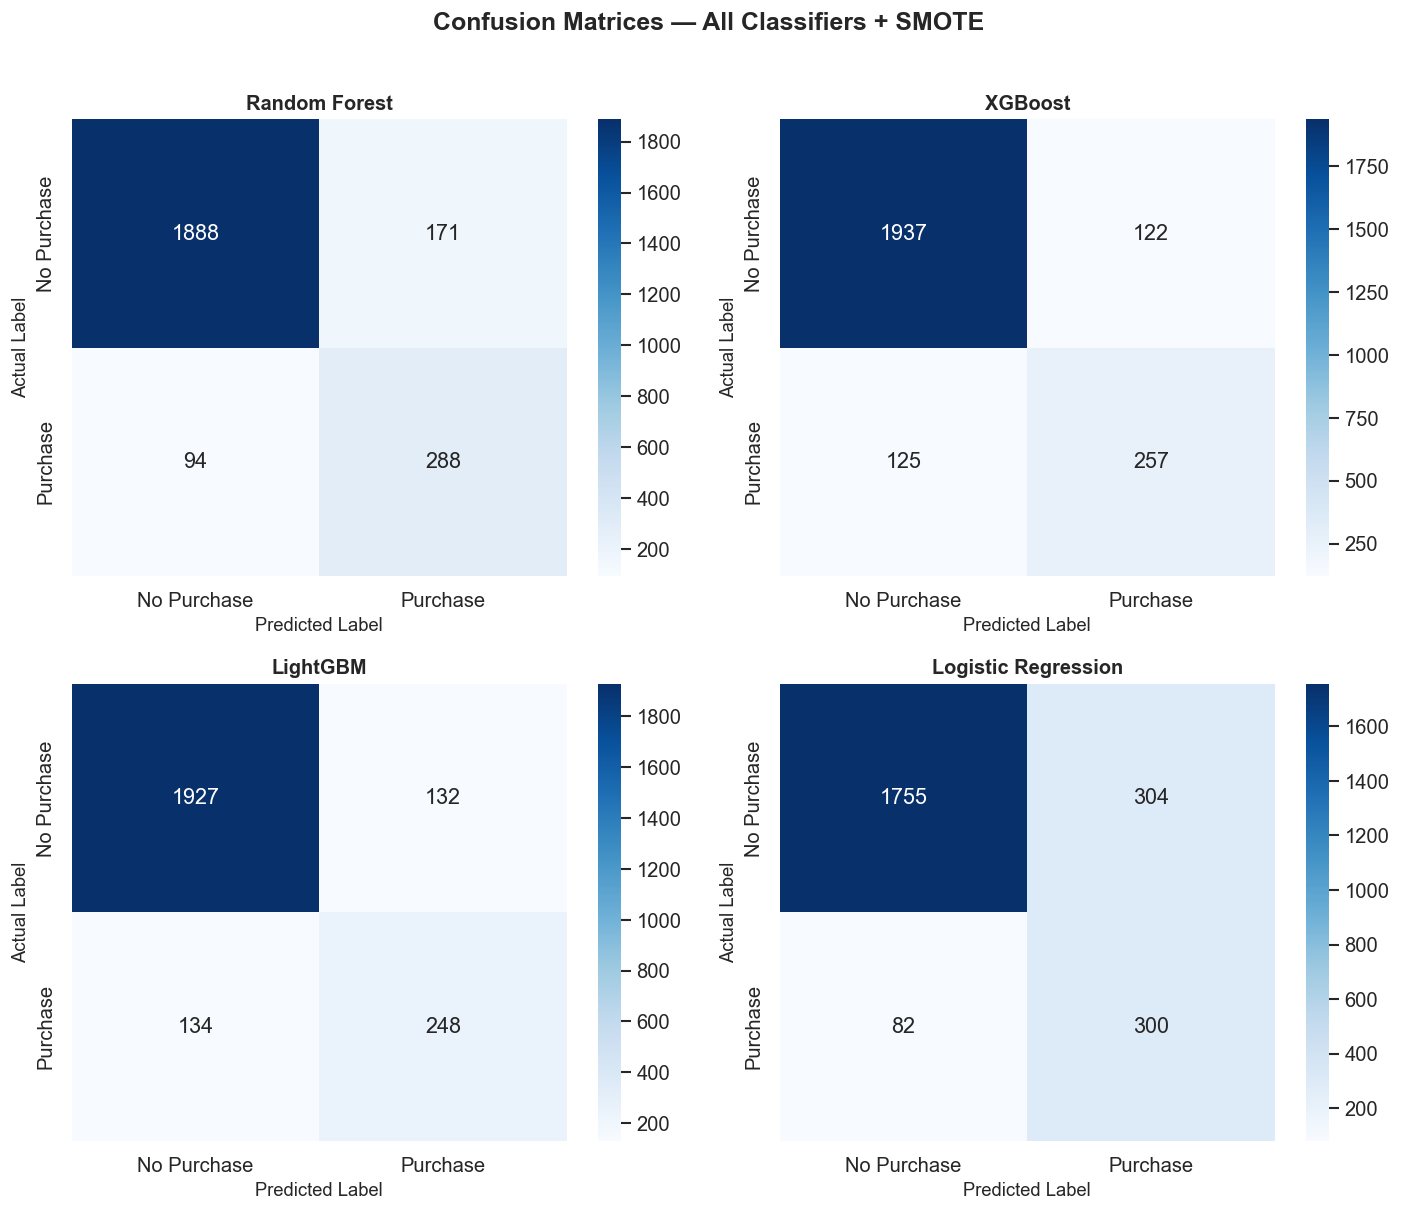

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, color) in enumerate(zip(pipelines.keys(), colors_bar)):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Purchase', 'Purchase'],
                yticklabels=['No Purchase', 'Purchase'],
                annot_kws={'size': 13})
    axes[i].set_title(f'{name}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('Actual Label')

plt.suptitle('Confusion Matrices — All Classifiers + SMOTE', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 23. ROC Curve Comparison — All Models

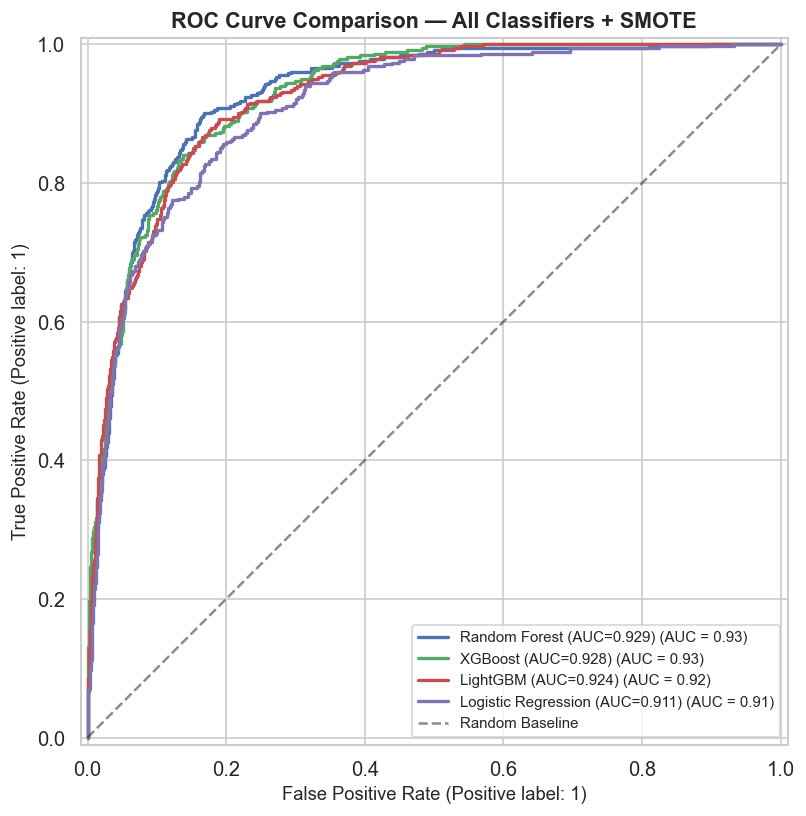

In [38]:
fig, ax = plt.subplots(figsize=(9, 7))

for name, color in zip(pipelines.keys(), colors_bar):
    auc_val = roc_auc_score(y_test, probabilities[name])
    RocCurveDisplay.from_predictions(y_test, probabilities[name], ax=ax,
                                      name=f'{name} (AUC={auc_val:.3f})',
                                      color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Baseline')
ax.set_title('ROC Curve Comparison — All Classifiers + SMOTE', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 24. Precision-Recall Curve Comparison

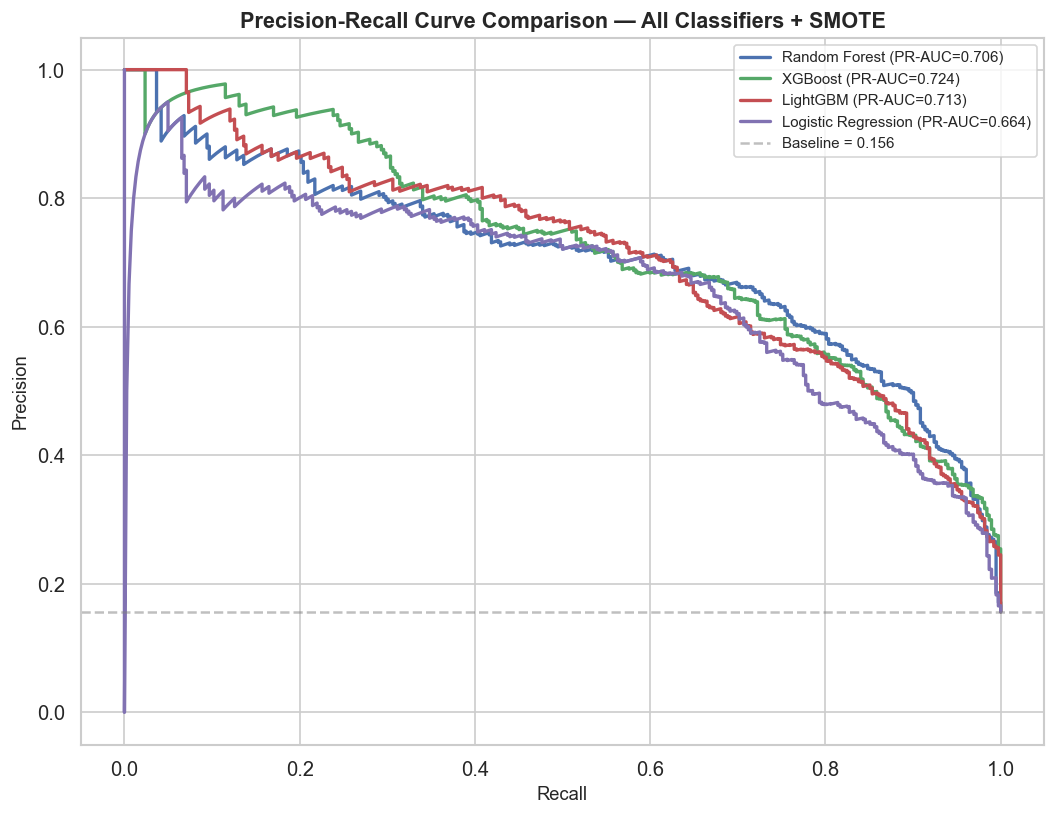

In [39]:
fig, ax = plt.subplots(figsize=(9, 7))

for name, color in zip(pipelines.keys(), colors_bar):
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, probabilities[name])
    pr_auc_val = auc(rec_vals, prec_vals)
    ax.plot(rec_vals, prec_vals, color=color, lw=2,
            label=f'{name} (PR-AUC={pr_auc_val:.3f})')

ax.axhline(y=y_test.mean(), color='grey', linestyle='--', alpha=0.5,
           label=f'Baseline = {y_test.mean():.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve Comparison — All Classifiers + SMOTE',
             fontweight='bold', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## 25. Feature Importance Analysis — Best Model
Feature importance is extracted from the **best-performing model** (by ROC-AUC). For tree-based models, we use built-in feature importance; for Logistic Regression, we use absolute coefficient values.

In [ ]:

best_model_name = results_df.iloc[0]['Model']
best_pipeline = trained_models[best_model_name]
best_classifier = best_pipeline.named_steps['classifier']

print(f"Best model by ROC-AUC: {best_model_name} ({results_df.iloc[0]['ROC-AUC']})")


encoded_cat_features = best_pipeline.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out(categorical_features)
all_feature_names = list(encoded_cat_features) + numerical_features


if hasattr(best_classifier, 'feature_importances_'):
    importances = best_classifier.feature_importances_
    imp_label = 'Feature Importance'
elif hasattr(best_classifier, 'coef_'):
    importances = np.abs(best_classifier.coef_[0])
    imp_label = 'Absolute Coefficient'
else:
    importances = np.zeros(len(all_feature_names))
    imp_label = 'N/A'

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(f"\nTop 15 Features ({imp_label}):")
importance_df.head(15)

Best model by ROC-AUC: Random Forest (0.9286)

Top 15 Features (Feature Importance):


,Feature,Importance
23,PageValues,0.451836
15,Administrative,0.058382
22,ExitRates,0.052966
7,Month_Nov,0.050441
20,ProductRelated_Duration,0.041386
16,Administrative_Duration,0.036026
30,Total_Duration,0.035624
28,TrafficType,0.031853
21,BounceRates,0.029421
19,ProductRelated,0.028790


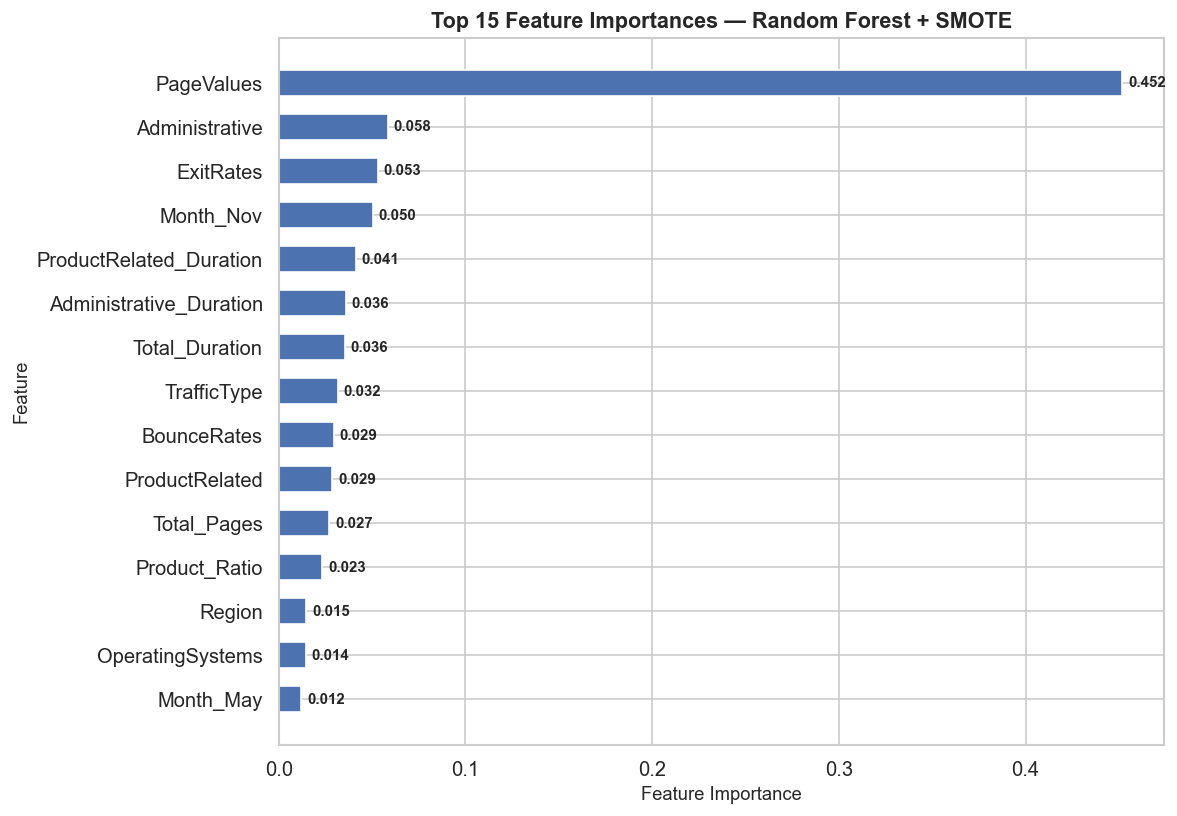


PageValues importance share: 45.18%


In [41]:
top_15 = importance_df.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_15['Feature'][::-1], top_15['Importance'][::-1],
               color='#4C72B0', edgecolor='white', height=0.6)

for bar, val in zip(bars, top_15['Importance'][::-1].values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax.set_title(f'Top 15 Feature Importances — {best_model_name} + SMOTE',
             fontweight='bold', fontsize=13)
ax.set_xlabel(imp_label)
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

if 'PageValues' in importance_df['Feature'].values:
    pv_imp = importance_df[importance_df['Feature'] == 'PageValues']['Importance'].values[0]
    print(f"\nPageValues importance share: {pv_imp:.2%}")

## 26. Feature Importance Comparison — Tree-Based Models

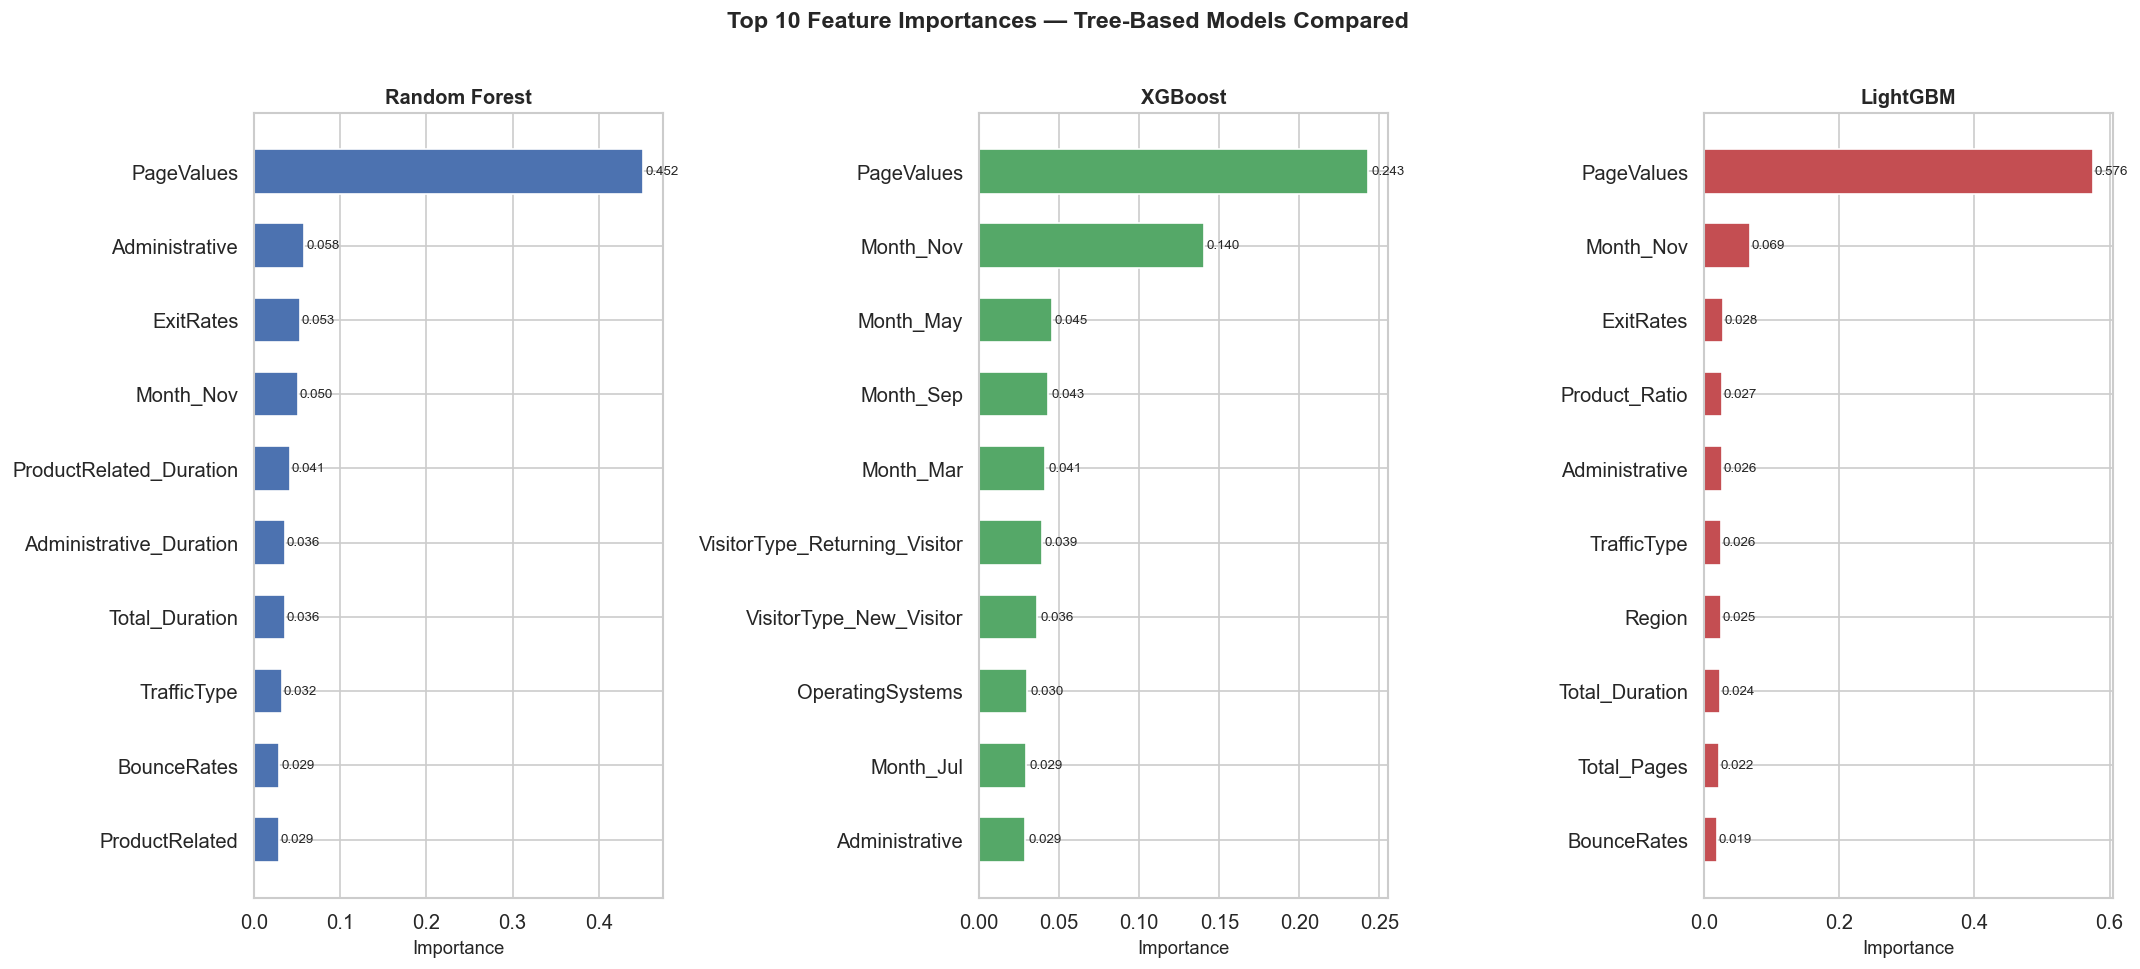

In [42]:
tree_models = {name: trained_models[name] for name in ['Random Forest', 'XGBoost', 'LightGBM']
               if name in trained_models}

fig, axes = plt.subplots(1, len(tree_models), figsize=(6 * len(tree_models), 8))
if len(tree_models) == 1:
    axes = [axes]

for ax, (name, pipeline), color in zip(axes, tree_models.items(), colors_bar[:3]):
    clf = pipeline.named_steps['classifier']
    imp = clf.feature_importances_
    imp_df_temp = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': imp
    }).sort_values('Importance', ascending=False).head(10)
    
    ax.barh(imp_df_temp['Feature'][::-1], imp_df_temp['Importance'][::-1],
            color=color, edgecolor='white', height=0.6)
    ax.set_title(f'{name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Importance')
    
    for bar, val in zip(ax.patches, imp_df_temp['Importance'][::-1].values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Top 10 Feature Importances — Tree-Based Models Compared',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 27. SMOTE Impact — Best Model With vs Without SMOTE
To demonstrate the impact of SMOTE, we train the best model **without** SMOTE and compare.

In [ ]:

from sklearn.pipeline import Pipeline as SkPipeline

if best_model_name == 'Random Forest':
    clf_no_smote = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_split=5,
                                           min_samples_leaf=2, random_state=42, n_jobs=-1)
elif best_model_name == 'XGBoost':
    clf_no_smote = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8,
                                  colsample_bytree=0.8, use_label_encoder=False,
                                  eval_metric='logloss', random_state=42, n_jobs=-1)
elif best_model_name == 'LightGBM':
    clf_no_smote = LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.1, subsample=0.8,
                                   colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1)
else:
    clf_no_smote = LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1)

no_smote_pipeline = SkPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', clf_no_smote)
])

no_smote_pipeline.fit(X_train, y_train)
y_pred_ns = no_smote_pipeline.predict(X_test)
y_proba_ns = no_smote_pipeline.predict_proba(X_test)[:, 1]

smote_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Purchase)', 'Recall (Purchase)', 'F1-Score (Purchase)', 'ROC-AUC'],
    f'{best_model_name} WITHOUT SMOTE': [
        round(accuracy_score(y_test, y_pred_ns), 4),
        round(precision_score(y_test, y_pred_ns), 4),
        round(recall_score(y_test, y_pred_ns), 4),
        round(f1_score(y_test, y_pred_ns), 4),
        round(roc_auc_score(y_test, y_proba_ns), 4)
    ],
    f'{best_model_name} WITH SMOTE': [
        round(accuracy_score(y_test, predictions[best_model_name]), 4),
        round(precision_score(y_test, predictions[best_model_name]), 4),
        round(recall_score(y_test, predictions[best_model_name]), 4),
        round(f1_score(y_test, predictions[best_model_name]), 4),
        round(roc_auc_score(y_test, probabilities[best_model_name]), 4)
    ]
})

print("=" * 70)
print(f"  SMOTE IMPACT — {best_model_name}")
print("=" * 70)
smote_comparison

  SMOTE IMPACT — Random Forest


,Metric,Random Forest WITHOUT SMOTE,Random Forest WITH SMOTE
0,Accuracy,0.9025,0.8914
1,Precision (Purchase),0.7535,0.6275
2,Recall (Purchase),0.5602,0.7539
3,F1-Score (Purchase),0.6426,0.6849
4,ROC-AUC,0.9298,0.9286


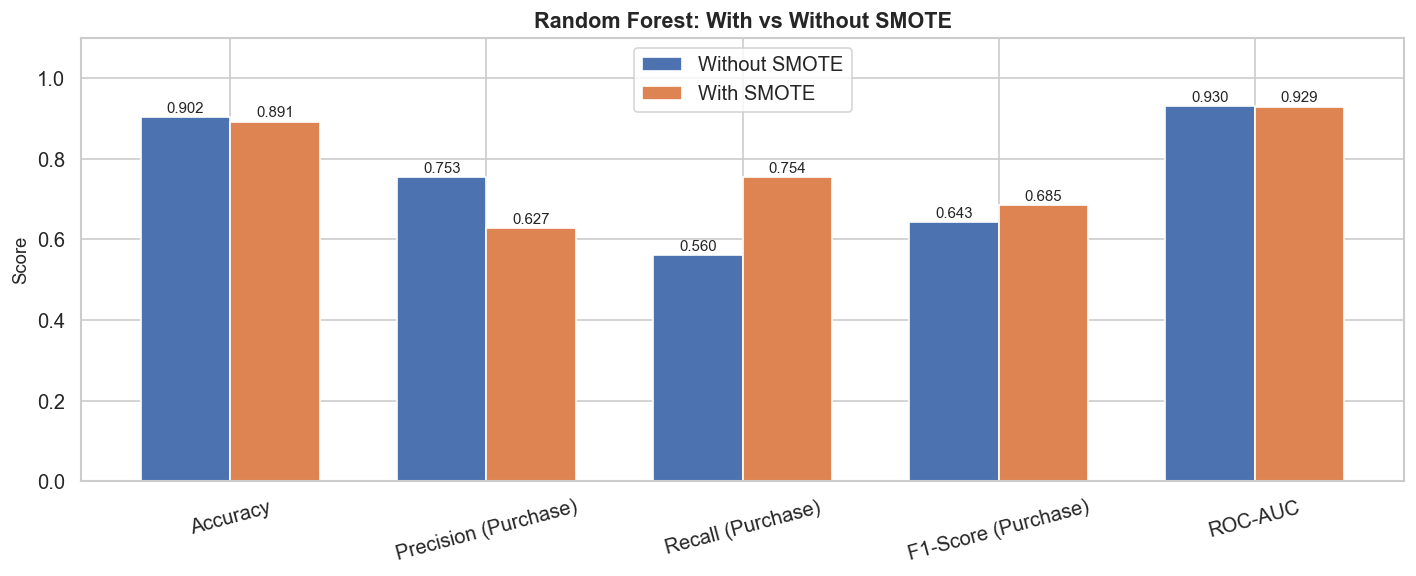

In [ ]:

metrics = smote_comparison['Metric'].tolist()
no_smote_vals = smote_comparison.iloc[:, 1].tolist()
smote_vals = smote_comparison.iloc[:, 2].tolist()

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, no_smote_vals, width, label='Without SMOTE', color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + width/2, smote_vals, width, label='With SMOTE', color='#DD8452', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score')
ax.set_title(f'{best_model_name}: With vs Without SMOTE', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

## 28. ROC Curve — SMOTE Impact

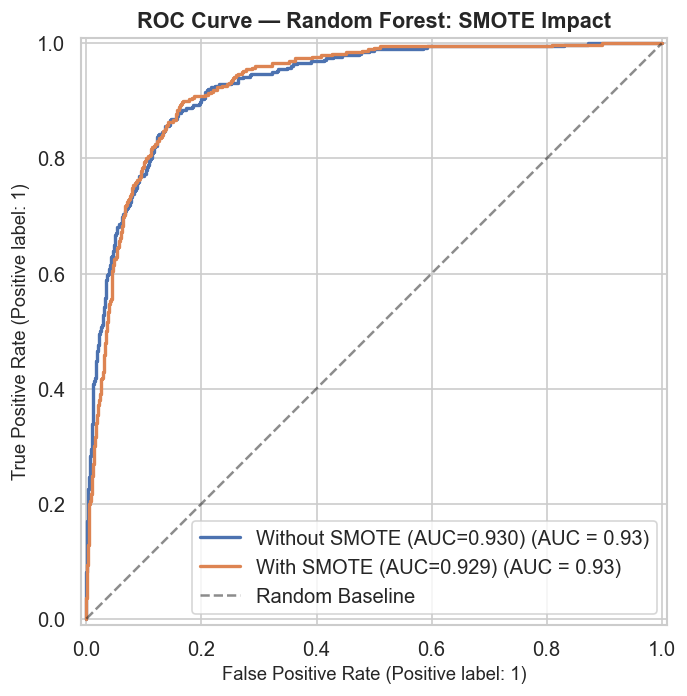

In [45]:
fig, ax = plt.subplots(figsize=(8, 6))

auc_ns = roc_auc_score(y_test, y_proba_ns)
auc_s = roc_auc_score(y_test, probabilities[best_model_name])

RocCurveDisplay.from_predictions(y_test, y_proba_ns, ax=ax,
                                  name=f'Without SMOTE (AUC={auc_ns:.3f})', color='#4C72B0', lw=2)
RocCurveDisplay.from_predictions(y_test, probabilities[best_model_name], ax=ax,
                                  name=f'With SMOTE (AUC={auc_s:.3f})', color='#DD8452', lw=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Baseline')

ax.set_title(f'ROC Curve — {best_model_name}: SMOTE Impact', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 29. Best Model Selection Summary

In [ ]:
print("=" * 80)
print("                    FINAL MODEL COMPARISON SUMMARY")
print("=" * 80)
print()


ranked = results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
ranked.index = ranked.index + 1
ranked.index.name = 'Rank'

print(ranked.to_string())

print(f"\n{'='*80}")
print(f"  BEST MODEL: {ranked.iloc[0]['Model']}")
print(f"  ROC-AUC: {ranked.iloc[0]['ROC-AUC']}  |  F1: {ranked.iloc[0]['F1-Score']}  |  Recall: {ranked.iloc[0]['Recall']}")
print(f"{'='*80}")

                    FINAL MODEL COMPARISON SUMMARY

                    Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Rank                                                                     
1           Random Forest    0.8914     0.6275  0.7539    0.6849   0.9286
2                 XGBoost    0.8988     0.6781  0.6728    0.6754   0.9276
3                LightGBM    0.8910     0.6526  0.6492    0.6509   0.9242
4     Logistic Regression    0.8419     0.4967  0.7853    0.6085   0.9107

  BEST MODEL: Random Forest
  ROC-AUC: 0.9286  |  F1: 0.6849  |  Recall: 0.7539
